# IC3392 OIII5006 high-S/N outlier inspection: SIII-tied use-trick test


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from astropy.io import fits

pd.set_option('display.max_columns', 180)
pd.set_option('display.max_rows', 260)
pd.set_option('display.max_colwidth', 180)

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 160,
    'axes.grid': False,
})

root = Path.cwd()
GALAXY = 'IC3392'
OIII_LINE = 'OIII5006'
OIII_LABEL = '[O III] 5006'
OIII_REST_A = 5006.843
REDSHIFT = 0.005566
C_KMS = 299792.458

RUNS = {
    'v768_7000_53_samebinning': {
        'label': 'v3tk_v7.6.8 7000/53 setup, same binning as 9100/40',
        'plot_label': '7.6.8 7000/53 same-bin',
        'gas_path': root / 'v3tk_v7.6.8_7000_samebinning' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
        'color': '#1f77b4',
    },
    'v768_9100_40_use_trick': {
        'label': 'v3tk_v7.6.8 9100/40 use-trick; SIII6312 tied with OIII group and SIII9068 tied to SIII6312',
        'plot_label': '7.6.8 9100/40 use-trick',
        'gas_path': root / 'v3tk_v7.6.8_VELSCALE40_use_trick' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
        'color': '#d62728',
    },
}
BASELINE_RUN = 'v768_7000_53_samebinning'
COMPARE_RUN = 'v768_9100_40_use_trick'
RUN_ORDER = [BASELINE_RUN, COMPARE_RUN]

CUBE_CANDIDATES = [
    root / '..' / 'v3tk_to_R' / 'IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3tk.fits',
    root / '..' / 'data' / GALAXY / 'IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3.fits',
]
CUBE_PATH = next((path for path in CUBE_CANDIDATES if path.exists()), None)

SNR_CUTS = [0, 3, 5, 10, 20, 50]
HIGH_SNR_CUT = 20
N_TOP_SIGMA = 6
N_TOP_VEL = 6
N_SPECTRA_TO_PLOT = 10

run_table = []
for run_key, run in RUNS.items():
    path = run['gas_path']
    run_table.append({
        'run_key': run_key,
        'label': run['label'],
        'gas_path': str(path.relative_to(root)),
        'exists': path.exists(),
        'size_MB': path.stat().st_size / 1024**2 if path.exists() else np.nan,
    })
run_table = pd.DataFrame(run_table)
display(run_table)
print('Cube path:', CUBE_PATH if CUBE_PATH is not None else 'No local cube found')
assert run_table['exists'].all(), 'Missing one or more GAS map files.'


,run_key,label,gas_path,exists,size_MB
0,v768_7000_53_samebinning,"v3tk_v7.6.8 7000/53 setup, same binning as 9100/40",v3tk_v7.6.8_7000_samebinning/IC3392/IC3392_gas_bin_maps.fits,True,152.251282
1,v768_9100_40_use_trick,v3tk_v7.6.8 9100/40 use-trick; SIII6312 tied with OIII group and SIII9068 tied to SIII6312,v3tk_v7.6.8_VELSCALE40_use_trick/IC3392/IC3392_gas_bin_maps.fits,True,162.498779


Cube path: /Users/Igniz/Desktop/ICRAR/further/../v3tk_to_R/IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3tk.fits


## Why This Test Is Careful

The hypothesis being tested is: if the 9100/40 rerun ties the SIII kinematics more deliberately, with `SIII6312` following the OIII kinematic group and `SIII9068` following `SIII6312`, the OIII5006 high-S/N outliers may move closer to the `7000/53 same-bin` reference or show a different failure pattern.

This notebook compares:

- reference: `v3tk_v7.6.8_7000_samebinning`, the 7000/53 setup rerun on the same binning scheme.
- comparison: `v3tk_v7.6.8_VELSCALE40_use_trick`, the 9100/40 setup using `emissionLines_ppxf_use_trick.config`.

The first code cell below verifies the actual run configs, compares the `use` and `use_trick` emission-line files, and checks the output GAS-map extensions. The OIII sections keep the same high-S/N ranking and selected-bin diagnostics from the 0513 notebook; the SIII section is kept because the SIII tying is the changed part of this rerun.

Important caveat: this is still a comparison between a 9100/40-style rerun and the 7000/53 same-bin reference. If OIII improves here, it supports the tied-line suspicion, but the interpretation still depends on the exact run configs and output products verified below.


In [2]:
CONFIG_PATHS = {
    'reference_7000_53_samebinning': root / 'v3tk_v7.6.8_7000_samebinning' / GALAXY / f'{GALAXY}_MAUVE_MasterConfig_v7.6.8_7000_samebinning_setonix.yaml',
    'full_9100_40_previous': root / 'v3tk_v7.6.8_VELSCALE40' / GALAXY / f'{GALAXY}_MAUVE_MasterConfig_v7.6.8_VELSCALE40_setonix.yaml',
    'plain_use_9100_40_previous': root / 'v3tk_v7.6.8_VELSCALE40_use' / GALAXY / f'{GALAXY}_MAUVE_MasterConfig_v7.6.8_VELSCALE40_use_setonix.yaml',
    'use_trick_9100_40_comparison': root / 'v3tk_v7.6.8_VELSCALE40_use_trick' / GALAXY / f'{GALAXY}_MAUVE_MasterConfig_v7.6.8_VELSCALE40_use_trick_setonix.yaml',
}
EMISSION_CONFIGS = {
    'full': root / 'emissionLines_ppxf_full.config',
    'use': root / 'emissionLines_ppxf_use.config',
    'use_trick': root / 'emissionLines_ppxf_use_trick.config',
}
COMPARISON_EMISSION_CONFIG_KEY = 'use_trick'


def read_simple_yaml(path):
    import yaml
    with open(path, 'r') as handle:
        return yaml.safe_load(handle)


def cfg_value(config, dotted_key):
    value = config
    for key in dotted_key.split('.'):
        if not isinstance(value, dict) or key not in value:
            return np.nan
        value = value[key]
    return value


def parse_emission_config(path):
    rows = []
    for lineno, raw_line in enumerate(path.read_text().splitlines(), start=1):
        stripped = raw_line.strip()
        if not stripped:
            continue
        commented = stripped.startswith('#')
        content = stripped.lstrip('#').strip() if commented else stripped
        parts = content.split()
        if len(parts) < 5 or not parts[0].isdigit():
            continue
        rest_air_a = float(parts[2])
        rows.append({
            'lineno': lineno,
            'index': int(parts[0]),
            'name': parts[1],
            'rest_air_a': rest_air_a,
            'line_id': f'{parts[1].upper()}{int(rest_air_a)}',
            'action': parts[3],
            'mode': parts[4],
            'commented_out': commented,
            'active_fit': (not commented) and parts[3] == 'f',
        })
    return pd.DataFrame(rows)


CONFIG_FIELDS = [
    'READ_DATA.LMIN_TOT', 'READ_DATA.LMAX_TOT', 'PREPARE_SPECTRA.VELSCALE',
    'KIN.METHOD', 'CONT.METHOD', 'GAS.METHOD', 'GAS.LEVEL', 'GAS.LMIN', 'GAS.LMAX',
    'GAS.MDEG', 'GAS.FIXED', 'GAS.MOM', 'GAS.EMI_FILE',
]
config_rows = []
for name, path in CONFIG_PATHS.items():
    if not path.exists():
        config_rows.append({'run': name, 'config_exists': False})
        continue
    config = read_simple_yaml(path)
    config_rows.append({'run': name, 'config_exists': True, **{field: cfg_value(config, field) for field in CONFIG_FIELDS}})
config_summary = pd.DataFrame(config_rows)
display(config_summary)

emission_tables = {name: parse_emission_config(path) for name, path in EMISSION_CONFIGS.items()}
active_line_rows = []
for name, table in emission_tables.items():
    active = table[table['active_fit']].copy()
    active_line_rows.append({
        'config': name,
        'n_active_fit_lines': int(len(active)),
        'active_line_ids': ', '.join(active['line_id'].tolist()),
        'active_k17_line_ids': ', '.join(active.loc[active['mode'].eq('k17'), 'line_id'].tolist()),
        'active_k23_line_ids': ', '.join(active.loc[active['mode'].eq('k23'), 'line_id'].tolist()),
    })
active_line_summary = pd.DataFrame(active_line_rows)
display(active_line_summary)

all_line_ids = sorted(set().union(*[set(table['line_id']) for table in emission_tables.values()]))
line_mode_audit = pd.DataFrame({'line_id': all_line_ids})
for name, table in emission_tables.items():
    indexed = table.set_index('line_id')
    line_mode_audit[f'active_in_{name}'] = line_mode_audit['line_id'].map(indexed['active_fit']).fillna(False).astype(bool)
    line_mode_audit[f'action_in_{name}'] = line_mode_audit['line_id'].map(indexed['action'])
    line_mode_audit[f'mode_in_{name}'] = line_mode_audit['line_id'].map(indexed['mode'])

line_mode_audit['use_to_trick_change'] = np.select(
    [
        line_mode_audit['active_in_use'].ne(line_mode_audit['active_in_use_trick']),
        line_mode_audit['action_in_use'].ne(line_mode_audit['action_in_use_trick']),
        line_mode_audit['mode_in_use'].ne(line_mode_audit['mode_in_use_trick']),
    ],
    ['active_fit_changed', 'action_changed', 'mode_changed'],
    default='unchanged',
)
display(line_mode_audit[line_mode_audit['use_to_trick_change'].ne('unchanged')])

with fits.open(RUNS[COMPARE_RUN]['gas_path'], memmap=False, ignore_missing_end=True) as hdul:
    comparison_extnames = {hdu.name for hdu in hdul}
comparison_flux_extensions = sorted(ext[:-5] for ext in comparison_extnames if ext.endswith('_FLUX'))
display(pd.DataFrame({'comparison_run_flux_extension_line_id': comparison_flux_extensions}))


,run,config_exists,READ_DATA.LMIN_TOT,READ_DATA.LMAX_TOT,PREPARE_SPECTRA.VELSCALE,KIN.METHOD,CONT.METHOD,GAS.METHOD,GAS.LEVEL,GAS.LMIN,GAS.LMAX,GAS.MDEG,GAS.FIXED,GAS.MOM,GAS.EMI_FILE
0,reference_7000_53_samebinning,True,4800,7000,53,ppxf,False,ppxf,BIN,4800,7000,8,True,2,emissionLines_ppxf.config
1,full_9100_40_previous,True,4800,9100,40,ppxf,ppxf,ppxf,BOTH,4800,9100,23,True,2,emissionLines_ppxf_full.config
2,plain_use_9100_40_previous,True,4800,9100,40,False,False,ppxf,BIN,4800,9100,23,True,2,emissionLines_ppxf_use.config
3,use_trick_9100_40_comparison,True,4800,9100,40,False,False,ppxf,BIN,4800,9100,23,True,2,emissionLines_ppxf_use_trick.config


,config,n_active_fit_lines,active_line_ids,active_k17_line_ids,active_k23_line_ids
0,full,23,"HEII4685, HB4861, OIII4958, OIII5006, NI5197, NI5200, NII5754, HEI5875, OI6300, SIII6312, OI6363, NII6548, HA6562, NII6583, SII6716, SII6730, ARIII7135, OII7318, OII7319, OII73...","HEII4685, HEI5875, SIII6312, ARIII7135, SIII9068, SIII9530",
1,use,15,"HB4861, OIII4958, OIII5006, NII5754, SIII6312, NII6548, HA6562, NII6583, SII6716, SII6730, OII7318, OII7319, OII7329, OII7330, SIII9068","SIII6312, SIII9068",
2,use_trick,15,"HB4861, OIII4958, OIII5006, NII5754, SIII6312, NII6548, HA6562, NII6583, SII6716, SII6730, OII7318, OII7319, OII7329, OII7330, SIII9068",SIII6312,SIII9068


,line_id,active_in_full,action_in_full,mode_in_full,active_in_use,action_in_use,mode_in_use,active_in_use_trick,action_in_use_trick,mode_in_use_trick,use_to_trick_change
37,SIII9068,True,f,k17,True,f,k17,True,f,k23,mode_changed


,comparison_run_flux_extension_line_id
0,HA6562
1,HB4861
2,NII5754
3,NII6548
4,NII6583
5,OII7318
6,OII7319
7,OII7329
8,OII7330
9,OIII4958


## Load OIII Maps And Verify Binning

Only the OIII HDUs are loaded. The `BIN_ID` maps must be exactly identical for the outlier ranking to be interpreted as a same-binning comparison. Here that check is between `7.6.8 7000/53 same-bin` and `7.6.8 9100/40 use-trick`.


,run_key,n_extensions,missing_oiii_extensions,all_oiii_available
0,v768_7000_53_samebinning,105,,True
1,v768_9100_40_use_trick,112,,True


,same_shape,exact_equal_including_nan,finite_pixels_in_both,n_finite_mismatches,n_unique_bins
0,True,True,94543,0,4032


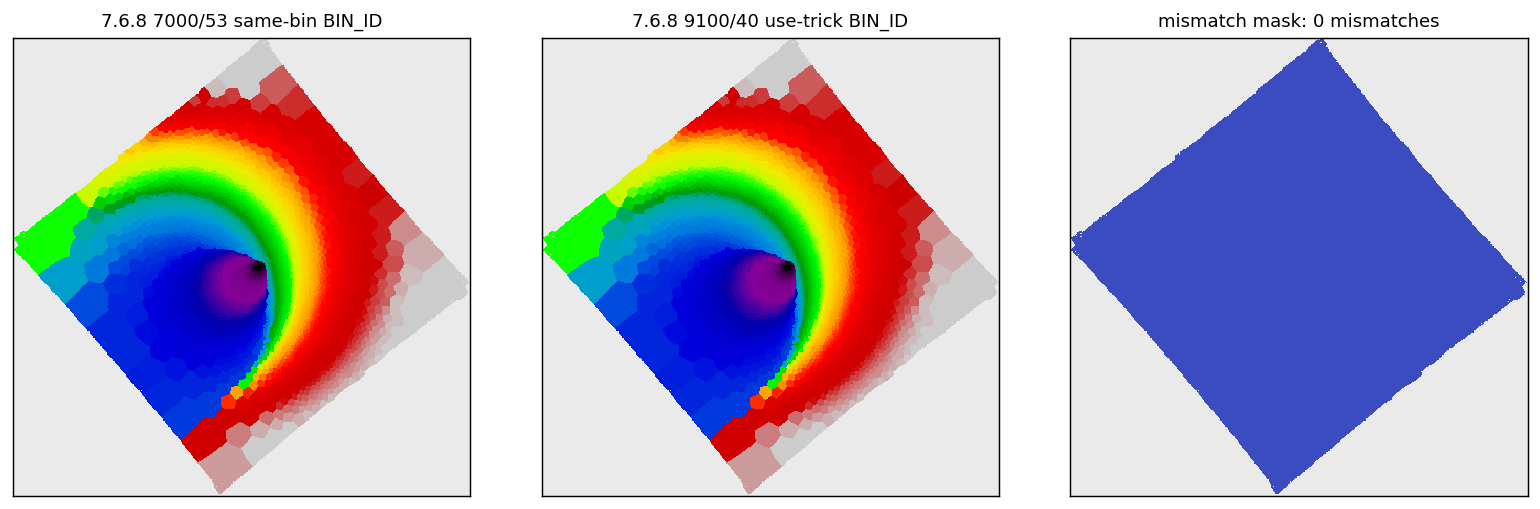

In [3]:
OIII_EXTENSIONS = [
    'BIN_ID',
    f'{OIII_LINE}_FLUX',
    f'{OIII_LINE}_FLUX_ERR',
    f'{OIII_LINE}_VEL',
    f'{OIII_LINE}_VEL_ERR',
    f'{OIII_LINE}_SIGMA',
    f'{OIII_LINE}_SIGMA_ERR',
    f'{OIII_LINE}_SIGMA_CORR',
]


def fits_extnames(path):
    with fits.open(path, memmap=False, ignore_missing_end=True) as hdul:
        return [hdu.name for hdu in hdul]


def read_map(path, extname):
    with fits.open(path, memmap=False, ignore_missing_end=True) as hdul:
        arr = np.array(hdul[extname].data, dtype=float)
    arr[~np.isfinite(arr)] = np.nan
    return arr


availability_rows = []
for run_key in RUN_ORDER:
    extnames = set(fits_extnames(RUNS[run_key]['gas_path']))
    missing = [ext for ext in OIII_EXTENSIONS if ext not in extnames]
    availability_rows.append({
        'run_key': run_key,
        'n_extensions': len(extnames),
        'missing_oiii_extensions': ', '.join(missing),
        'all_oiii_available': len(missing) == 0,
    })
availability = pd.DataFrame(availability_rows)
display(availability)
assert availability['all_oiii_available'].all(), 'Required OIII extensions are missing.'

maps = {
    extname: {run_key: read_map(RUNS[run_key]['gas_path'], extname) for run_key in RUN_ORDER}
    for extname in OIII_EXTENSIONS
}

baseline_bins = maps['BIN_ID'][BASELINE_RUN]
compare_bins = maps['BIN_ID'][COMPARE_RUN]
same_shape = baseline_bins.shape == compare_bins.shape
exact_equal = bool(same_shape and np.array_equal(baseline_bins, compare_bins, equal_nan=True))
finite_both = np.isfinite(baseline_bins) & np.isfinite(compare_bins)
n_mismatch = int(np.count_nonzero(finite_both & (baseline_bins != compare_bins))) if same_shape else np.nan
binning_check = pd.DataFrame([{
    'same_shape': same_shape,
    'exact_equal_including_nan': exact_equal,
    'finite_pixels_in_both': int(finite_both.sum()) if same_shape else np.nan,
    'n_finite_mismatches': n_mismatch,
    'n_unique_bins': int(np.unique(baseline_bins[np.isfinite(baseline_bins) & (baseline_bins >= 0)]).size),
}])
display(binning_check)
assert exact_equal, 'The two runs do not have identical BIN_ID maps.'

fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.8), constrained_layout=True)
cmap_bins = plt.get_cmap('nipy_spectral').copy()
cmap_bins.set_bad('0.92')
cmap_mismatch = plt.get_cmap('coolwarm').copy()
cmap_mismatch.set_bad('0.92')
for ax, arr, title in [
    (axes[0], baseline_bins, f'{RUNS[BASELINE_RUN]["plot_label"]} BIN_ID'),
    (axes[1], compare_bins, f'{RUNS[COMPARE_RUN]["plot_label"]} BIN_ID'),
]:
    ax.imshow(np.ma.masked_invalid(arr), origin='lower', cmap=cmap_bins, interpolation='nearest')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
mismatch = np.full(baseline_bins.shape, np.nan, dtype=float)
mismatch[finite_both] = baseline_bins[finite_both] != compare_bins[finite_both]
axes[2].imshow(mismatch, origin='lower', cmap=cmap_mismatch, vmin=0, vmax=1, interpolation='nearest')
axes[2].set_title(f'mismatch mask: {n_mismatch} mismatches', fontsize=10)
axes[2].set_xticks([])
axes[2].set_yticks([])
plt.show()


## Build One-Row-Per-Bin OIII Table

The GAS maps are image-shaped, so this table collapses each `BIN_ID` to one median row. It keeps OIII flux/error, velocity, sigma, formal errors, residuals, ratios, and bin-center coordinates.


In [4]:
def line_fluxerr(run_key):
    flux = maps[f'{OIII_LINE}_FLUX'][run_key]
    err = maps[f'{OIII_LINE}_FLUX_ERR'][run_key]
    ratio = np.full(flux.shape, np.nan, dtype=float)
    valid = np.isfinite(flux) & np.isfinite(err) & (err > 0)
    ratio[valid] = flux[valid] / err[valid]
    return ratio


def robust_sigma(values):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    return float(0.5 * (np.nanpercentile(values, 84) - np.nanpercentile(values, 16)))


fluxerr_maps = {run_key: line_fluxerr(run_key) for run_key in RUN_ORDER}
rows, cols = np.indices(baseline_bins.shape)
valid_bin_pixels = np.isfinite(baseline_bins) & (baseline_bins >= 0)

pixel_table = pd.DataFrame({
    'bin_id': baseline_bins[valid_bin_pixels].astype(int),
    'row': rows[valid_bin_pixels].astype(float),
    'col': cols[valid_bin_pixels].astype(float),
})
for run_key in RUN_ORDER:
    prefix = 'ref' if run_key == BASELINE_RUN else 'cmp'
    pixel_table[f'{prefix}_flux'] = maps[f'{OIII_LINE}_FLUX'][run_key][valid_bin_pixels]
    pixel_table[f'{prefix}_fluxerr'] = fluxerr_maps[run_key][valid_bin_pixels]
    pixel_table[f'{prefix}_vel'] = maps[f'{OIII_LINE}_VEL'][run_key][valid_bin_pixels]
    pixel_table[f'{prefix}_vel_err'] = maps[f'{OIII_LINE}_VEL_ERR'][run_key][valid_bin_pixels]
    pixel_table[f'{prefix}_sigma'] = maps[f'{OIII_LINE}_SIGMA'][run_key][valid_bin_pixels]
    pixel_table[f'{prefix}_sigma_err'] = maps[f'{OIII_LINE}_SIGMA_ERR'][run_key][valid_bin_pixels]
    pixel_table[f'{prefix}_sigma_corr'] = maps[f'{OIII_LINE}_SIGMA_CORR'][run_key][valid_bin_pixels]

agg = {col: 'median' for col in pixel_table.columns if col != 'bin_id'}
agg['row'] = 'median'
agg['col'] = 'median'
bin_table = pixel_table.groupby('bin_id', as_index=False).agg(agg)
bin_table['n_spaxels'] = pixel_table.groupby('bin_id').size().to_numpy()

bin_table['both_fluxerr_min'] = bin_table[['ref_fluxerr', 'cmp_fluxerr']].min(axis=1)
bin_table['delta_vel'] = bin_table['cmp_vel'] - bin_table['ref_vel']
bin_table['abs_delta_vel'] = np.abs(bin_table['delta_vel'])
bin_table['delta_sigma'] = bin_table['cmp_sigma'] - bin_table['ref_sigma']
bin_table['abs_delta_sigma'] = np.abs(bin_table['delta_sigma'])
bin_table['sigma_ratio'] = bin_table['cmp_sigma'] / bin_table['ref_sigma']
bin_table.loc[~np.isfinite(bin_table['sigma_ratio']) | (bin_table['sigma_ratio'] <= 0), 'sigma_ratio'] = np.nan
bin_table['log10_sigma_ratio'] = np.log10(bin_table['sigma_ratio'])
bin_table['abs_log10_sigma_ratio'] = np.abs(bin_table['log10_sigma_ratio'])

vel_err_quad = np.sqrt(bin_table['ref_vel_err']**2 + bin_table['cmp_vel_err']**2)
sigma_err_quad = np.sqrt(bin_table['ref_sigma_err']**2 + bin_table['cmp_sigma_err']**2)
bin_table['delta_vel_over_formal_err'] = bin_table['delta_vel'] / vel_err_quad.replace(0, np.nan)
bin_table['delta_sigma_over_formal_err'] = bin_table['delta_sigma'] / sigma_err_quad.replace(0, np.nan)
bin_table['abs_delta_vel_over_formal_err'] = np.abs(bin_table['delta_vel_over_formal_err'])
bin_table['abs_delta_sigma_over_formal_err'] = np.abs(bin_table['delta_sigma_over_formal_err'])

summary_cols = [
    'bin_id', 'row', 'col', 'n_spaxels', 'ref_fluxerr', 'cmp_fluxerr', 'both_fluxerr_min',
    'ref_vel', 'cmp_vel', 'delta_vel', 'abs_delta_vel', 'ref_sigma', 'cmp_sigma',
    'delta_sigma', 'abs_delta_sigma', 'sigma_ratio', 'log10_sigma_ratio',
    'ref_vel_err', 'cmp_vel_err', 'ref_sigma_err', 'cmp_sigma_err',
]
display(bin_table[summary_cols].head())
print(f'One row per OIII bin: {len(bin_table):,}')


,bin_id,row,col,n_spaxels,ref_fluxerr,cmp_fluxerr,both_fluxerr_min,ref_vel,cmp_vel,delta_vel,abs_delta_vel,ref_sigma,cmp_sigma,delta_sigma,abs_delta_sigma,sigma_ratio,log10_sigma_ratio,ref_vel_err,cmp_vel_err,ref_sigma_err,cmp_sigma_err
0,0,219.0,233.0,1,10.379920,10.232329,10.232329,24.346302,26.188713,1.842411,1.842411,82.276645,78.409070,-3.867576,3.867576,0.952993,-0.020910,11.200067,10.846813,17.990619,18.915845
1,1,219.0,234.0,1,8.815816,7.781492,7.781492,1.666905,-57.824251,-59.491156,59.491156,93.455133,199.237801,105.782668,105.782668,2.131909,0.328769,15.391011,25.568968,21.088208,26.656009
2,2,218.0,234.0,1,9.841161,6.603486,6.603486,14.226059,-22.220667,-36.446726,36.446726,64.616388,173.458530,108.842142,108.842142,2.684436,0.428853,9.384720,20.494724,66.950492,20.719138
3,3,218.0,233.0,1,11.095179,10.166121,10.166121,13.638244,-3.981460,-17.619705,17.619705,97.317618,168.336077,71.018459,71.018459,1.729760,0.237986,12.432965,17.896100,16.768479,18.059987
4,4,218.0,235.0,1,7.866447,6.210363,6.210363,63.026453,16.290052,-46.736401,46.736401,101.964187,184.727422,82.763236,82.763236,1.811689,0.258084,18.397380,25.259272,24.542005,26.142478


One row per OIII bin: 4,032


## OIII S/N Population And Outlier Ranking

The high-S/N working sample defaults to bins with `Flux/Err > 20` in both runs. The selected-bin list is the union of the largest `abs(log10 sigma ratio)` bins and the largest `abs(delta velocity)` bins in that high-S/N sample.


In [5]:
population_rows = []
for cut in SNR_CUTS:
    subset = bin_table[bin_table['both_fluxerr_min'] > cut]
    population_rows.append({
        'fluxerr_cut_in_both_runs': f'>{cut:g}',
        'n_bins': int(len(subset)),
        'fraction_of_bins': float(len(subset) / len(bin_table)),
        'median_ref_fluxerr': float(np.nanmedian(subset['ref_fluxerr'])) if len(subset) else np.nan,
        'median_cmp_fluxerr': float(np.nanmedian(subset['cmp_fluxerr'])) if len(subset) else np.nan,
        'median_delta_vel': float(np.nanmedian(subset['delta_vel'])) if len(subset) else np.nan,
        'robust_sigma_delta_vel': robust_sigma(subset['delta_vel']) if len(subset) else np.nan,
        'median_delta_sigma': float(np.nanmedian(subset['delta_sigma'])) if len(subset) else np.nan,
        'robust_sigma_delta_sigma': robust_sigma(subset['delta_sigma']) if len(subset) else np.nan,
        'median_sigma_ratio': float(np.nanmedian(subset['sigma_ratio'])) if len(subset) else np.nan,
        'robust_sigma_log10_ratio': robust_sigma(subset['log10_sigma_ratio']) if len(subset) else np.nan,
    })
population_summary = pd.DataFrame(population_rows)
display(population_summary)

high_snr = bin_table[
    (bin_table['both_fluxerr_min'] > HIGH_SNR_CUT)
    & np.isfinite(bin_table['delta_vel'])
    & np.isfinite(bin_table['log10_sigma_ratio'])
].copy()

sigma_outliers = high_snr.sort_values('abs_log10_sigma_ratio', ascending=False).head(N_TOP_SIGMA).copy()
sigma_outliers['candidate_reason'] = 'large sigma ratio'
vel_outliers = high_snr.sort_values('abs_delta_vel', ascending=False).head(N_TOP_VEL).copy()
vel_outliers['candidate_reason'] = 'large velocity difference'
candidates = pd.concat([sigma_outliers, vel_outliers], ignore_index=True)
reason_by_bin = candidates.groupby('bin_id')['candidate_reason'].apply(lambda values: '; '.join(sorted(set(values))))
selected_bins = (
    high_snr[high_snr['bin_id'].isin(reason_by_bin.index)]
    .copy()
    .assign(selection_reason=lambda df: df['bin_id'].map(reason_by_bin))
    .sort_values(['abs_log10_sigma_ratio', 'abs_delta_vel'], ascending=False)
)

if len(selected_bins) < N_SPECTRA_TO_PLOT:
    filler = (
        high_snr[~high_snr['bin_id'].isin(selected_bins['bin_id'])]
        .copy()
        .assign(selection_reason='next largest combined deviation')
        .sort_values(['abs_log10_sigma_ratio', 'abs_delta_vel'], ascending=False)
        .head(N_SPECTRA_TO_PLOT - len(selected_bins))
    )
    selected_bins = pd.concat([selected_bins, filler], ignore_index=True)

selected_bins = selected_bins.head(N_SPECTRA_TO_PLOT).reset_index(drop=True)

selected_cols = [
    'selection_reason', 'bin_id', 'row', 'col', 'n_spaxels', 'both_fluxerr_min',
    'ref_fluxerr', 'cmp_fluxerr', 'delta_vel', 'abs_delta_vel',
    'delta_sigma', 'abs_delta_sigma', 'sigma_ratio', 'log10_sigma_ratio',
    'ref_vel', 'cmp_vel', 'ref_sigma', 'cmp_sigma',
    'abs_delta_vel_over_formal_err', 'abs_delta_sigma_over_formal_err',
]
display(selected_bins[selected_cols])

print(f'High-S/N OIII bins with Flux/Err > {HIGH_SNR_CUT:g} in both runs: {len(high_snr):,}')
print(f'Selected most-deviated bins for visual inspection: {len(selected_bins):,}')


,fluxerr_cut_in_both_runs,n_bins,fraction_of_bins,median_ref_fluxerr,median_cmp_fluxerr,median_delta_vel,robust_sigma_delta_vel,median_delta_sigma,robust_sigma_delta_sigma,median_sigma_ratio,robust_sigma_log10_ratio
0,>0,3992,0.990079,9.057891,8.677845,-0.924696,33.689202,2.336181,28.360793,1.029725,0.104892
1,>3,3801,0.942708,9.274445,8.902706,-0.826566,30.634577,2.034752,27.949281,1.024056,0.102723
2,>5,3379,0.838046,9.699088,9.361040,-0.778091,25.947928,2.119248,26.636927,1.025444,0.097997
3,>10,1369,0.339534,12.399634,12.276139,-0.935322,15.497315,3.225889,19.913738,1.038138,0.072733
4,>20,59,0.014633,24.016560,24.495221,-0.479328,3.323788,6.476915,8.120248,1.065027,0.033772
5,>50,1,0.000248,52.031861,52.627349,-1.316244,0.000000,1.988482,0.000000,1.022555,0.000000


,selection_reason,bin_id,row,col,n_spaxels,both_fluxerr_min,ref_fluxerr,cmp_fluxerr,delta_vel,abs_delta_vel,delta_sigma,abs_delta_sigma,sigma_ratio,log10_sigma_ratio,ref_vel,cmp_vel,ref_sigma,cmp_sigma,abs_delta_vel_over_formal_err,abs_delta_sigma_over_formal_err
0,large sigma ratio,3277,200.0,292.0,8,20.713541,20.713541,20.840936,-2.793866,2.793866,49.236136,49.236136,1.479786,0.170199,-21.449641,-24.243507,102.621033,151.857170,0.257916,3.843510
1,large sigma ratio,908,87.0,187.0,451,22.660587,22.660587,23.426256,0.680095,0.680095,46.513475,46.513475,1.392603,0.143827,4.913349,5.593444,118.474543,164.988019,0.059384,3.850154
2,large sigma ratio; large velocity difference,2369,304.0,162.0,16,20.805057,22.320831,20.805057,23.610582,23.610582,-23.341800,23.341800,0.743223,-0.128881,100.166363,123.776945,90.903007,67.561208,3.896499,2.562774
3,large sigma ratio,2310,229.5,256.5,4,20.717998,20.820768,20.717998,-6.264355,6.264355,31.556958,31.556958,1.327945,0.123180,-2.560149,-8.824504,96.226285,127.783243,0.661843,2.698551
4,large sigma ratio; large velocity difference,2358,297.5,192.0,10,20.273606,21.097449,20.273606,16.344419,16.344419,-23.733490,23.733490,0.754240,-0.122491,104.934936,121.279355,96.571649,72.838159,2.316795,2.380661
5,large sigma ratio,347,195.0,213.0,11,26.351823,26.576036,26.351823,-1.151883,1.151883,-26.091676,26.091676,0.761710,-0.118210,29.486577,28.334694,109.495352,83.403676,0.187685,3.412310
6,large velocity difference,2254,296.0,190.0,9,20.819538,21.201866,20.819538,11.348891,11.348891,-19.395025,19.395025,0.806384,-0.093458,107.904101,119.252992,100.172819,80.777793,1.509941,1.963356
7,large velocity difference,2349,298.5,188.0,10,21.927822,22.075691,21.927822,21.450538,21.450538,-9.107714,9.107714,0.891533,-0.049863,104.666720,126.117258,83.967301,74.859587,3.586917,0.981397
8,large velocity difference,381,193.0,211.0,11,34.876029,35.873955,34.876029,-14.933557,14.933557,-12.755271,12.755271,0.893577,-0.048868,59.726059,44.792501,119.854143,107.098872,2.681261,1.934251
9,large velocity difference,3354,164.0,284.0,9,21.644525,22.233704,21.644525,-14.696608,14.696608,4.268911,4.268911,1.046468,0.019726,-50.901795,-65.598404,91.868532,96.137444,1.865995,0.381192


High-S/N OIII bins with Flux/Err > 20 in both runs: 59
Selected most-deviated bins for visual inspection: 10


## Quick Context: Previous Full/Plain-Use 9100/40 Versus Use-Trick 9100/40

The rest of this notebook uses the `use-trick` run as the comparison run. This small table keeps the old full-line `9100/40` result and the plain used-line `9100/40` result nearby as context, using the same 7000/53 same-bin reference and the same one-row-per-bin OIII summary logic. If the SIII tying changes the OIII behavior, its residuals, sigma ratio, and robust scatter can be compared directly against those earlier reruns at the same `Flux/Err` cuts.


In [6]:
CONTEXT_COMPARISON_RUNS = [
    {
        'key': 'full_9100_40_previous',
        'plot_label': '7.6.8 9100/40 full-line',
        'gas_path': root / 'v3tk_v7.6.8_VELSCALE40' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
    },
    {
        'key': 'plain_use_9100_40_previous',
        'plot_label': '7.6.8 9100/40 plain used-lines',
        'gas_path': root / 'v3tk_v7.6.8_VELSCALE40_use' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
    },
]


def one_row_per_bin_for_comparison(compare_path):
    compare_maps = {
        ext: read_map(compare_path, 'BIN_ID' if ext == 'BIN_ID' else f'{OIII_LINE}_{ext}')
        for ext in ['BIN_ID', 'FLUX', 'FLUX_ERR', 'VEL', 'VEL_ERR', 'SIGMA', 'SIGMA_ERR']
    }
    compare_fluxerr = np.full(compare_maps['FLUX'].shape, np.nan, dtype=float)
    ok = np.isfinite(compare_maps['FLUX']) & np.isfinite(compare_maps['FLUX_ERR']) & (compare_maps['FLUX_ERR'] > 0)
    compare_fluxerr[ok] = compare_maps['FLUX'][ok] / compare_maps['FLUX_ERR'][ok]

    rows, cols = np.indices(baseline_bins.shape)
    valid = np.isfinite(baseline_bins) & (baseline_bins >= 0)
    table = pd.DataFrame({
        'bin_id': baseline_bins[valid].astype(int),
        'row': rows[valid].astype(float),
        'col': cols[valid].astype(float),
        'ref_fluxerr': fluxerr_maps[BASELINE_RUN][valid],
        'cmp_fluxerr': compare_fluxerr[valid],
        'ref_vel': maps[f'{OIII_LINE}_VEL'][BASELINE_RUN][valid],
        'cmp_vel': compare_maps['VEL'][valid],
        'ref_sigma': maps[f'{OIII_LINE}_SIGMA'][BASELINE_RUN][valid],
        'cmp_sigma': compare_maps['SIGMA'][valid],
    })
    out = table.groupby('bin_id', as_index=False).median(numeric_only=True)
    out['both_fluxerr_min'] = out[['ref_fluxerr', 'cmp_fluxerr']].min(axis=1)
    out['delta_vel'] = out['cmp_vel'] - out['ref_vel']
    out['delta_sigma'] = out['cmp_sigma'] - out['ref_sigma']
    out['sigma_ratio'] = out['cmp_sigma'] / out['ref_sigma']
    out.loc[~np.isfinite(out['sigma_ratio']) | (out['sigma_ratio'] <= 0), 'sigma_ratio'] = np.nan
    out['log10_sigma_ratio'] = np.log10(out['sigma_ratio'])
    return out


comparison_tables = {
    RUNS[COMPARE_RUN]['plot_label']: bin_table,
}
for run in CONTEXT_COMPARISON_RUNS:
    comparison_tables[run['plot_label']] = one_row_per_bin_for_comparison(run['gas_path'])

context_rows = []
for label, table in comparison_tables.items():
    for cut in [10, 20, 50]:
        subset = table[
            (table['both_fluxerr_min'] > cut)
            & np.isfinite(table['delta_vel'])
            & np.isfinite(table['delta_sigma'])
            & np.isfinite(table['log10_sigma_ratio'])
        ]
        context_rows.append({
            'comparison_run': label,
            'fluxerr_cut_in_both_runs': f'>{cut:g}',
            'n_bins': int(len(subset)),
            'median_delta_vel': float(np.nanmedian(subset['delta_vel'])) if len(subset) else np.nan,
            'robust_sigma_delta_vel': robust_sigma(subset['delta_vel']) if len(subset) else np.nan,
            'median_delta_sigma': float(np.nanmedian(subset['delta_sigma'])) if len(subset) else np.nan,
            'robust_sigma_delta_sigma': robust_sigma(subset['delta_sigma']) if len(subset) else np.nan,
            'median_sigma_ratio': float(np.nanmedian(subset['sigma_ratio'])) if len(subset) else np.nan,
            'robust_sigma_log10_ratio': robust_sigma(subset['log10_sigma_ratio']) if len(subset) else np.nan,
        })
full_plain_use_vs_use_trick_context = pd.DataFrame(context_rows)
display(full_plain_use_vs_use_trick_context)


,comparison_run,fluxerr_cut_in_both_runs,n_bins,median_delta_vel,robust_sigma_delta_vel,median_delta_sigma,robust_sigma_delta_sigma,median_sigma_ratio,robust_sigma_log10_ratio
0,7.6.8 9100/40 use-trick,>10,1369,-0.935322,15.497315,3.225889,19.913738,1.038138,0.072733
1,7.6.8 9100/40 use-trick,>20,59,-0.479328,3.323788,6.476915,8.120248,1.065027,0.033772
2,7.6.8 9100/40 use-trick,>50,1,-1.316244,0.000000,1.988482,0.000000,1.022555,0.000000
3,7.6.8 9100/40 full-line,>10,1361,-1.136025,15.589451,2.804637,19.543203,1.034372,0.071268
4,7.6.8 9100/40 full-line,>20,59,-0.724511,3.290024,6.508748,7.818408,1.062135,0.034192
5,7.6.8 9100/40 full-line,>50,1,-1.312984,0.000000,2.036835,0.000000,1.023103,0.000000
6,7.6.8 9100/40 plain used-lines,>10,1369,-0.935322,15.497315,3.225889,19.913738,1.038138,0.072733
7,7.6.8 9100/40 plain used-lines,>20,59,-0.479328,3.323788,6.476915,8.120248,1.065027,0.033772
8,7.6.8 9100/40 plain used-lines,>50,1,-1.316244,0.000000,1.988482,0.000000,1.022555,0.000000


## OIII Maps With Selected Bins

These maps show where the selected suspicious bins sit relative to OIII signal-to-noise, velocity residuals, and sigma-ratio structure.


### How The Map Diagnostic Figure Is Built

The next cell plots image-space OIII diagnostics from the two already-loaded GAS map files. The background maps use all finite OIII map pixels, not only the high-S/N subset, so you can see where the suspicious bins sit in the full galaxy context.

The plotted quantities are:

- `Flux/Err` in the `7000/53 same-bin` run.
- `Flux/Err` in the `9100/40` run.
- the minimum of the two `Flux/Err` maps, which shows where both runs have usable OIII signal.
- `delta VEL = VEL_9100/40 - VEL_7000/53_samebin`.
- `delta SIGMA = SIGMA_9100/40 - SIGMA_7000/53_samebin`.
- `log10(SIGMA_9100/40 / SIGMA_7000/53_samebin)`.

The black circles are the `selected_bins` from the previous ranking cell. Their positions are the median row/column of all spaxels in that `BIN_ID`, and the text labels are the bin IDs. Color limits are robust: percentile limits for Flux/Err maps, and symmetric percentile limits for residual/ratio maps, so a few extreme pixels do not flatten the useful contrast.


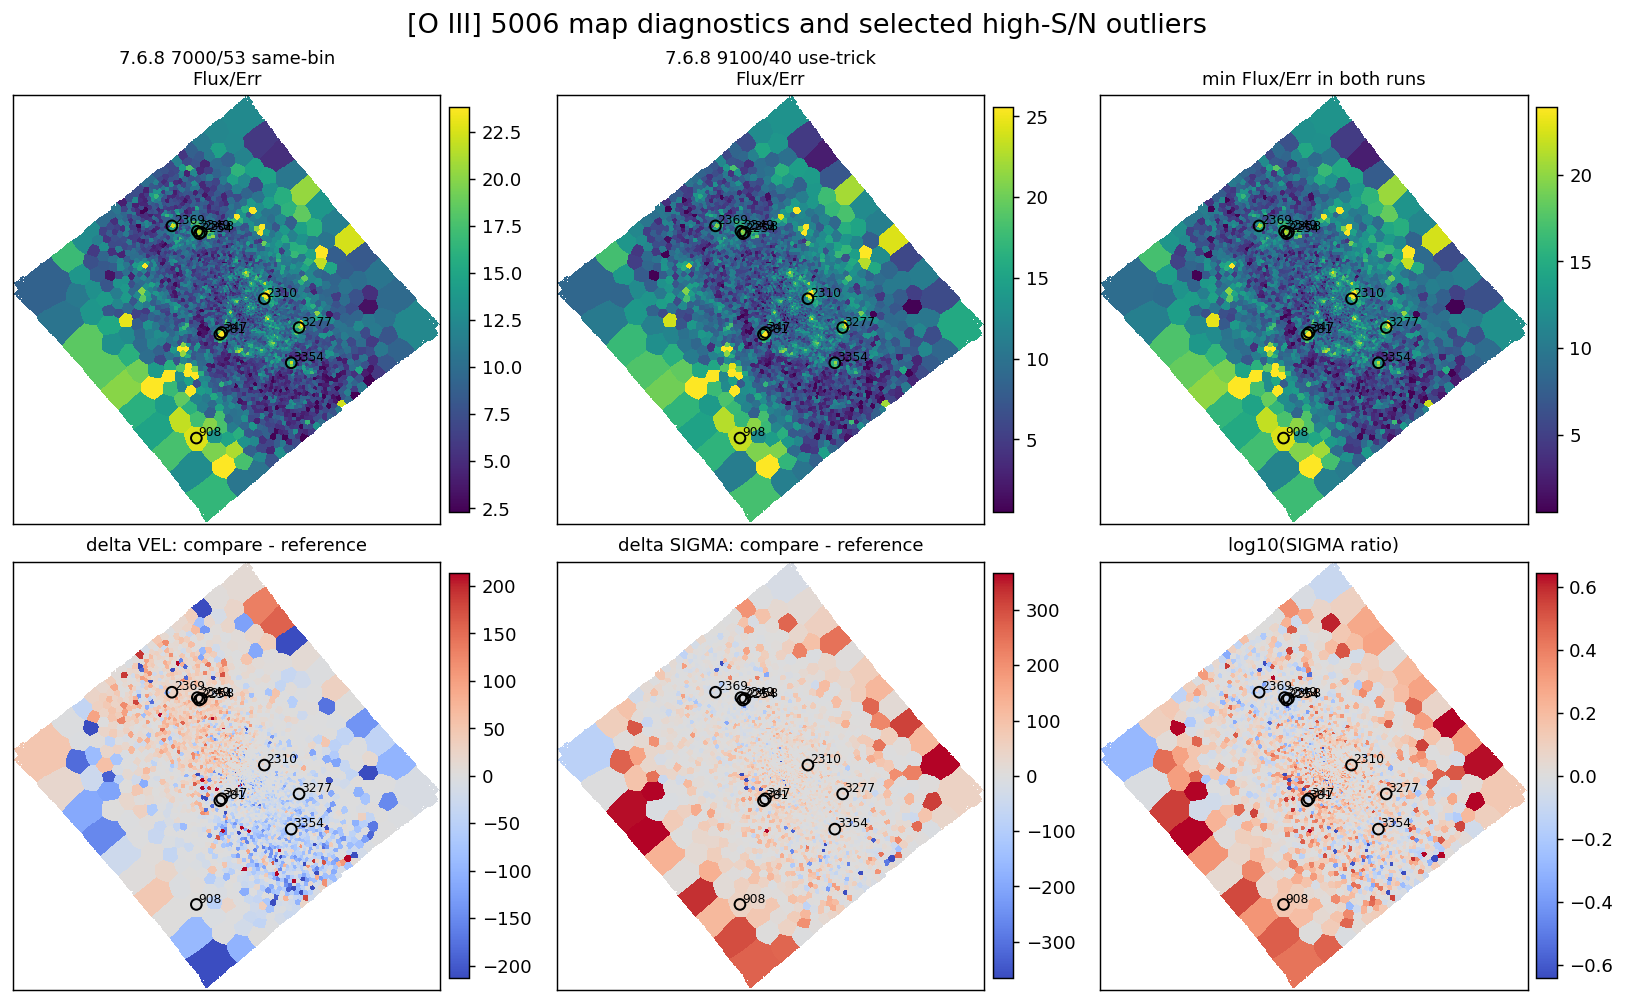

In [7]:
def robust_limits(values, p=(2, 98), pad_fraction=0.06, fallback=(-1, 1)):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return fallback
    lo, hi = np.nanpercentile(values, p)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        center = np.nanmedian(values)
        spread = np.nanstd(values)
        spread = spread if np.isfinite(spread) and spread > 0 else 1.0
        lo, hi = center - spread, center + spread
    pad = pad_fraction * (hi - lo)
    return float(lo - pad), float(hi + pad)


def symmetric_limit(values, percentile=98, fallback=1.0):
    values = np.abs(np.asarray(values)[np.isfinite(values)])
    if values.size == 0:
        return fallback
    limit = np.nanpercentile(values, percentile)
    return float(limit if np.isfinite(limit) and limit > 0 else fallback)


delta_vel_map = maps[f'{OIII_LINE}_VEL'][COMPARE_RUN] - maps[f'{OIII_LINE}_VEL'][BASELINE_RUN]
delta_sigma_map = maps[f'{OIII_LINE}_SIGMA'][COMPARE_RUN] - maps[f'{OIII_LINE}_SIGMA'][BASELINE_RUN]
sigma_ratio_map = maps[f'{OIII_LINE}_SIGMA'][COMPARE_RUN] / maps[f'{OIII_LINE}_SIGMA'][BASELINE_RUN]
sigma_ratio_map[~np.isfinite(sigma_ratio_map) | (sigma_ratio_map <= 0)] = np.nan
log_sigma_ratio_map = np.log10(sigma_ratio_map)

fig, axes = plt.subplots(2, 3, figsize=(12.5, 7.6), constrained_layout=True)
fig.suptitle(f'{OIII_LABEL} map diagnostics and selected high-S/N outliers', fontsize=15)

panels = [
    (axes[0, 0], fluxerr_maps[BASELINE_RUN], f'{RUNS[BASELINE_RUN]["plot_label"]}\nFlux/Err', 'viridis', None),
    (axes[0, 1], fluxerr_maps[COMPARE_RUN], f'{RUNS[COMPARE_RUN]["plot_label"]}\nFlux/Err', 'viridis', None),
    (axes[0, 2], np.minimum(fluxerr_maps[BASELINE_RUN], fluxerr_maps[COMPARE_RUN]), 'min Flux/Err in both runs', 'viridis', None),
    (axes[1, 0], delta_vel_map, 'delta VEL: compare - reference', 'coolwarm', symmetric_limit(delta_vel_map, 98, 25)),
    (axes[1, 1], delta_sigma_map, 'delta SIGMA: compare - reference', 'coolwarm', symmetric_limit(delta_sigma_map, 98, 25)),
    (axes[1, 2], log_sigma_ratio_map, 'log10(SIGMA ratio)', 'coolwarm', symmetric_limit(log_sigma_ratio_map, 98, 0.3)),
]

for ax, arr, title, cmap, lim in panels:
    plot_arr = np.ma.masked_invalid(arr)
    if lim is None:
        vmin, vmax = robust_limits(arr, p=(2, 98), fallback=(0, 20))
        im = ax.imshow(plot_arr, origin='lower', cmap=cmap, vmin=max(vmin, 0), vmax=vmax, interpolation='nearest')
    else:
        im = ax.imshow(plot_arr, origin='lower', cmap=cmap, vmin=-lim, vmax=lim, interpolation='nearest')
    ax.scatter(selected_bins['col'], selected_bins['row'], s=35, facecolors='none', edgecolors='black', linewidths=1.1)
    for _, row in selected_bins.iterrows():
        ax.text(row['col'] + 2, row['row'] + 2, str(int(row['bin_id'])), fontsize=6.8, color='black')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

plt.show()


## OIII Pairwise And Ratio Views

Selected bins are highlighted on the same OIII-only pairwise views used for ranking.


### How The Pairwise/Ratio Plot Data Is Selected

The next cell switches from image pixels to the one-row-per-bin table. The gray point cloud is `high_snr`, defined in the ranking cell as bins with:

`min(Flux/Err_7000/53_samebin, Flux/Err_9100/40) > HIGH_SNR_CUT`

where `HIGH_SNR_CUT = 20` by default. This keeps the pairwise views focused on bins where OIII is at least plausibly measured in both runs.

The highlighted/labeled points are the same `selected_bins`: the union of the largest sigma-ratio outliers and the largest velocity-difference outliers. The four panels show velocity agreement, velocity residuals, sigma agreement in log-log space, and the sigma ratio as `log10(SIGMA_9100/40 / SIGMA_7000/53_samebin)`.


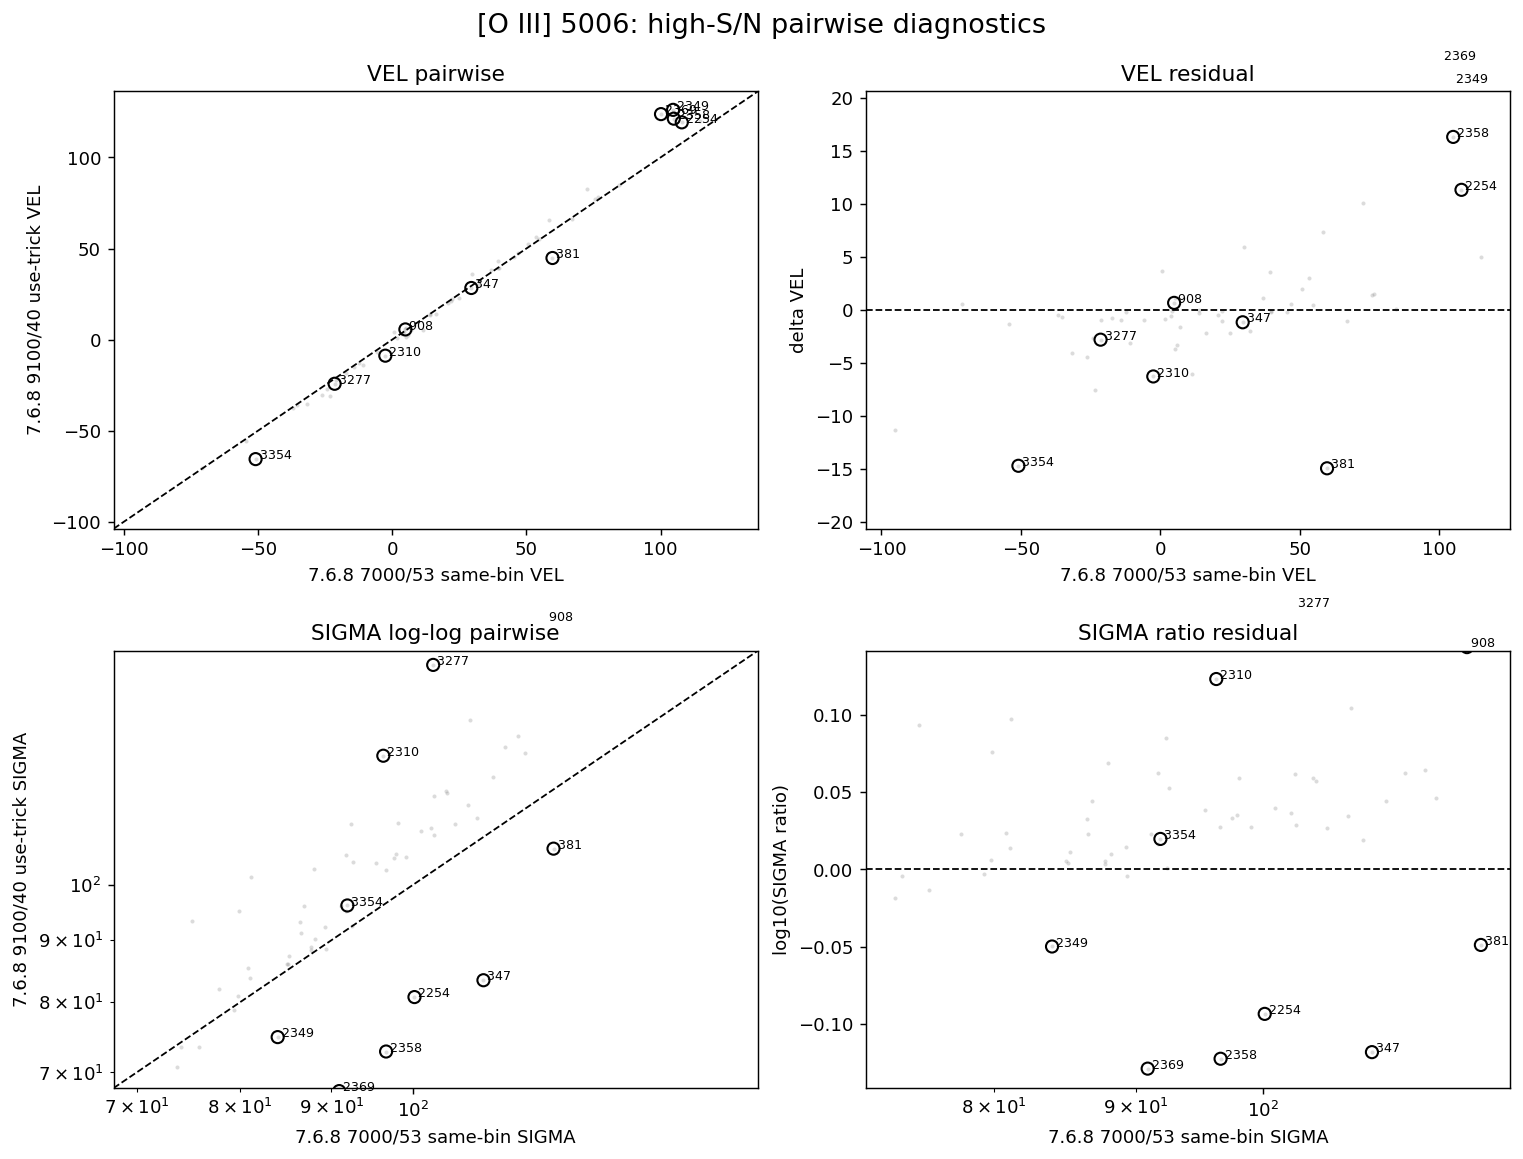

In [8]:
def scatter_selected(ax, x_col, y_col, color='black'):
    ax.scatter(selected_bins[x_col], selected_bins[y_col], s=45, facecolors='none', edgecolors=color, linewidths=1.15, zorder=5)
    for _, row in selected_bins.iterrows():
        ax.text(row[x_col], row[y_col], f' {int(row["bin_id"])}', fontsize=7, color=color, zorder=6)


fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.8), constrained_layout=True)
fig.suptitle(f'{OIII_LABEL}: high-S/N pairwise diagnostics', fontsize=15)

plot_sample = high_snr.copy()
if len(plot_sample) > 25000:
    plot_sample = plot_sample.sample(25000, random_state=12)

ax = axes[0, 0]
lo, hi = robust_limits(high_snr[['ref_vel', 'cmp_vel']].to_numpy().ravel(), p=(1, 99), fallback=(-150, 150))
ax.scatter(plot_sample['ref_vel'], plot_sample['cmp_vel'], s=5, alpha=0.25, linewidths=0, color='0.45')
ax.plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=1)
scatter_selected(ax, 'ref_vel', 'cmp_vel')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} VEL')
ax.set_ylabel(f'{RUNS[COMPARE_RUN]["plot_label"]} VEL')
ax.set_title('VEL pairwise')

ax = axes[0, 1]
vel_lim = symmetric_limit(high_snr['delta_vel'], 98, 25)
ax.scatter(plot_sample['ref_vel'], plot_sample['delta_vel'], s=5, alpha=0.25, linewidths=0, color='0.45')
ax.scatter(selected_bins['ref_vel'], selected_bins['delta_vel'], s=45, facecolors='none', edgecolors='black', linewidths=1.15)
for _, row in selected_bins.iterrows():
    ax.text(row['ref_vel'], row['delta_vel'], f' {int(row["bin_id"])}', fontsize=7)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_ylim(-vel_lim, vel_lim)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} VEL')
ax.set_ylabel('delta VEL')
ax.set_title('VEL residual')

ax = axes[1, 0]
sigma_values = high_snr[['ref_sigma', 'cmp_sigma']].to_numpy().ravel()
sigma_values = sigma_values[np.isfinite(sigma_values) & (sigma_values > 0)]
slo_log, shi_log = robust_limits(np.log10(sigma_values), p=(1, 99), fallback=(np.log10(30), np.log10(400)))
slo, shi = 10**slo_log, 10**shi_log
ax.scatter(plot_sample['ref_sigma'], plot_sample['cmp_sigma'], s=5, alpha=0.25, linewidths=0, color='0.45')
ax.plot([slo, shi], [slo, shi], color='black', linestyle='--', linewidth=1)
scatter_selected(ax, 'ref_sigma', 'cmp_sigma')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(slo, shi)
ax.set_ylim(slo, shi)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} SIGMA')
ax.set_ylabel(f'{RUNS[COMPARE_RUN]["plot_label"]} SIGMA')
ax.set_title('SIGMA log-log pairwise')

ax = axes[1, 1]
log_lim = symmetric_limit(high_snr['log10_sigma_ratio'], 98, 0.3)
ax.scatter(plot_sample['ref_sigma'], plot_sample['log10_sigma_ratio'], s=5, alpha=0.25, linewidths=0, color='0.45')
ax.scatter(selected_bins['ref_sigma'], selected_bins['log10_sigma_ratio'], s=45, facecolors='none', edgecolors='black', linewidths=1.15)
for _, row in selected_bins.iterrows():
    ax.text(row['ref_sigma'], row['log10_sigma_ratio'], f' {int(row["bin_id"])}', fontsize=7)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_ylim(-log_lim, log_lim)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} SIGMA')
ax.set_ylabel('log10(SIGMA ratio)')
ax.set_title('SIGMA ratio residual')

plt.show()


## Quick-Look Spectral Inspection Around OIII

This section extracts observed spectra from the local IC3392 cube for the current use-trick-selected bins. It uses the shared `BIN_ID` map, locally subtracts a linear continuum, then overlays two Gaussian profiles with centers/sigmas implied by the GAS maps. The amplitude is refit against the locally continuum-subtracted spectrum, so this is a shape/center sanity check rather than a reproduction of the full pPXF fit.


In [9]:
def wavelength_from_header(header, n_wave):
    crpix = header.get('CRPIX3', 1.0)
    crval = header.get('CRVAL3')
    cdelt = header.get('CDELT3', header.get('CD3_3'))
    if crval is None or cdelt is None:
        raise ValueError('Cannot construct wavelength vector from cube header.')
    return crval + (np.arange(n_wave) + 1 - crpix) * cdelt


def gaussian_unit(wave, center, sigma_a):
    if not np.isfinite(center) or not np.isfinite(sigma_a) or sigma_a <= 0:
        return np.full(wave.shape, np.nan)
    return np.exp(-0.5 * ((wave - center) / sigma_a) ** 2)


def fitted_gaussian_for_run(wave, spectrum_contsub, row, run_key, line_window_mask):
    prefix = 'ref' if run_key == BASELINE_RUN else 'cmp'
    vel = row[f'{prefix}_vel']
    sigma_kms = row[f'{prefix}_sigma']
    center = OIII_REST_A * (1.0 + REDSHIFT) * (1.0 + vel / C_KMS)
    sigma_a = center * sigma_kms / C_KMS
    profile = gaussian_unit(wave, center, sigma_a)
    fit_mask = line_window_mask & np.isfinite(profile) & np.isfinite(spectrum_contsub)
    if fit_mask.sum() < 3:
        amp = np.nan
        model = np.full(wave.shape, np.nan)
        rms = np.nan
    else:
        denom = np.nansum(profile[fit_mask] ** 2)
        amp = np.nansum(spectrum_contsub[fit_mask] * profile[fit_mask]) / denom if denom > 0 else np.nan
        model = amp * profile
        rms = np.sqrt(np.nanmean((spectrum_contsub[fit_mask] - model[fit_mask]) ** 2))
    return {
        'center': center,
        'sigma_a': sigma_a,
        'amp': amp,
        'model': model,
        'rms': rms,
        'vel': vel,
        'sigma_kms': sigma_kms,
    }


def extract_selected_bin_spectra(selected, wave_half_width=35.0, line_half_width=9.0, continuum_inner=14.0):
    if CUBE_PATH is None:
        print('No local cube found; skipping spectral extraction.')
        return []

    systemic_center = OIII_REST_A * (1.0 + REDSHIFT)
    with fits.open(CUBE_PATH, memmap=True) as hdul:
        cube = hdul['DATA'].data
        var = hdul['STAT'].data if 'STAT' in hdul else None
        wave = wavelength_from_header(hdul['DATA'].header, cube.shape[0])
        wave_mask = (wave >= systemic_center - wave_half_width) & (wave <= systemic_center + wave_half_width)
        wave_cut = wave[wave_mask]
        cube_cut = np.array(cube[wave_mask, :, :], dtype=float)
        var_cut = np.array(var[wave_mask, :, :], dtype=float) if var is not None else None

    line_window = np.abs(wave_cut - systemic_center) <= line_half_width
    continuum_window = (np.abs(wave_cut - systemic_center) >= continuum_inner) & np.isfinite(wave_cut)
    spectra = []

    for _, row in selected.iterrows():
        bin_id = int(row['bin_id'])
        bin_mask = baseline_bins == bin_id
        if not np.any(bin_mask):
            continue
        spectrum = np.nansum(cube_cut[:, bin_mask], axis=1)
        if var_cut is not None:
            variance = np.nansum(var_cut[:, bin_mask], axis=1)
            noise = np.sqrt(np.clip(variance, 0, np.inf))
        else:
            noise = np.full_like(spectrum, np.nan)

        continuum_fit_mask = continuum_window & np.isfinite(spectrum)
        if continuum_fit_mask.sum() >= 4:
            coeff = np.polyfit(wave_cut[continuum_fit_mask], spectrum[continuum_fit_mask], deg=1)
            continuum = np.polyval(coeff, wave_cut)
        else:
            continuum = np.full_like(spectrum, np.nanmedian(spectrum))
        contsub = spectrum - continuum

        ref_fit = fitted_gaussian_for_run(wave_cut, contsub, row, BASELINE_RUN, line_window)
        cmp_fit = fitted_gaussian_for_run(wave_cut, contsub, row, COMPARE_RUN, line_window)
        spectra.append({
            'bin_id': bin_id,
            'row': row,
            'wave': wave_cut,
            'spectrum': spectrum,
            'noise': noise,
            'continuum': continuum,
            'contsub': contsub,
            'line_window': line_window,
            'ref_fit': ref_fit,
            'cmp_fit': cmp_fit,
        })
    return spectra


spectra_to_plot = selected_bins.head(N_SPECTRA_TO_PLOT).copy()
selected_spectra = extract_selected_bin_spectra(spectra_to_plot)
print(f'Extracted spectra for {len(selected_spectra)} current use-trick-selected bins.')


Extracted spectra for 10 current use-trick-selected bins.


### How The Spectral Quick-Look Panels Are Constructed

The previous cell creates `selected_spectra` from the local MUSE cube, not from a pre-existing continuum-subtracted cube product. These panels use the current use-trick-selected `selected_bins`, i.e. the bins ranked as suspicious after comparing `7000/53 same-bin` against `9100/40 use-trick`.

The steps are:

1. Choose the first `N_SPECTRA_TO_PLOT` rows of the current `selected_bins`. This is set to `10`, matching the 10 selected suspicious bins.
2. Open the local cube from `CUBE_PATH`, using the `DATA` HDU for flux and the `STAT` HDU for variance.
3. Build the wavelength vector from the cube header using `CRVAL3`, `CRPIX3`, and `CD3_3`/`CDELT3`.
4. Cut a narrow wavelength slab around systemic OIII: `OIII_REST_A * (1 + REDSHIFT)` plus/minus `35 Angstrom`.
5. For each selected `BIN_ID`, sum all cube spaxels belonging to that bin to make an observed binned spectrum.
6. Fit a local linear continuum using side-band pixels outside the central OIII region, then subtract that continuum. So “continuum-subtracted” here means a local quick-look subtraction made in this notebook, not the full pPXF stellar-continuum solution.
7. Sum the `STAT` variance over the same bin spaxels and take the square root; this is the gray `1 sigma noise` band.
8. Construct one Gaussian model per run using that run's map-level OIII `VEL` and `SIGMA` for the selected bin. The Gaussian center is `lambda_rest * (1 + z) * (1 + VEL/c)`, and the width is `sigma_lambda = center * SIGMA/c`.
9. Refit only the Gaussian amplitude against the local continuum-subtracted cube spectrum inside the central line window. This makes the overlay a center/width sanity check, not a reproduction of the full pPXF model or flux solution.

The orange shaded region is the central OIII line window, plus/minus `9 Angstrom` around systemic OIII. That window is used for the quick amplitude fit and the RMS number printed in each panel.


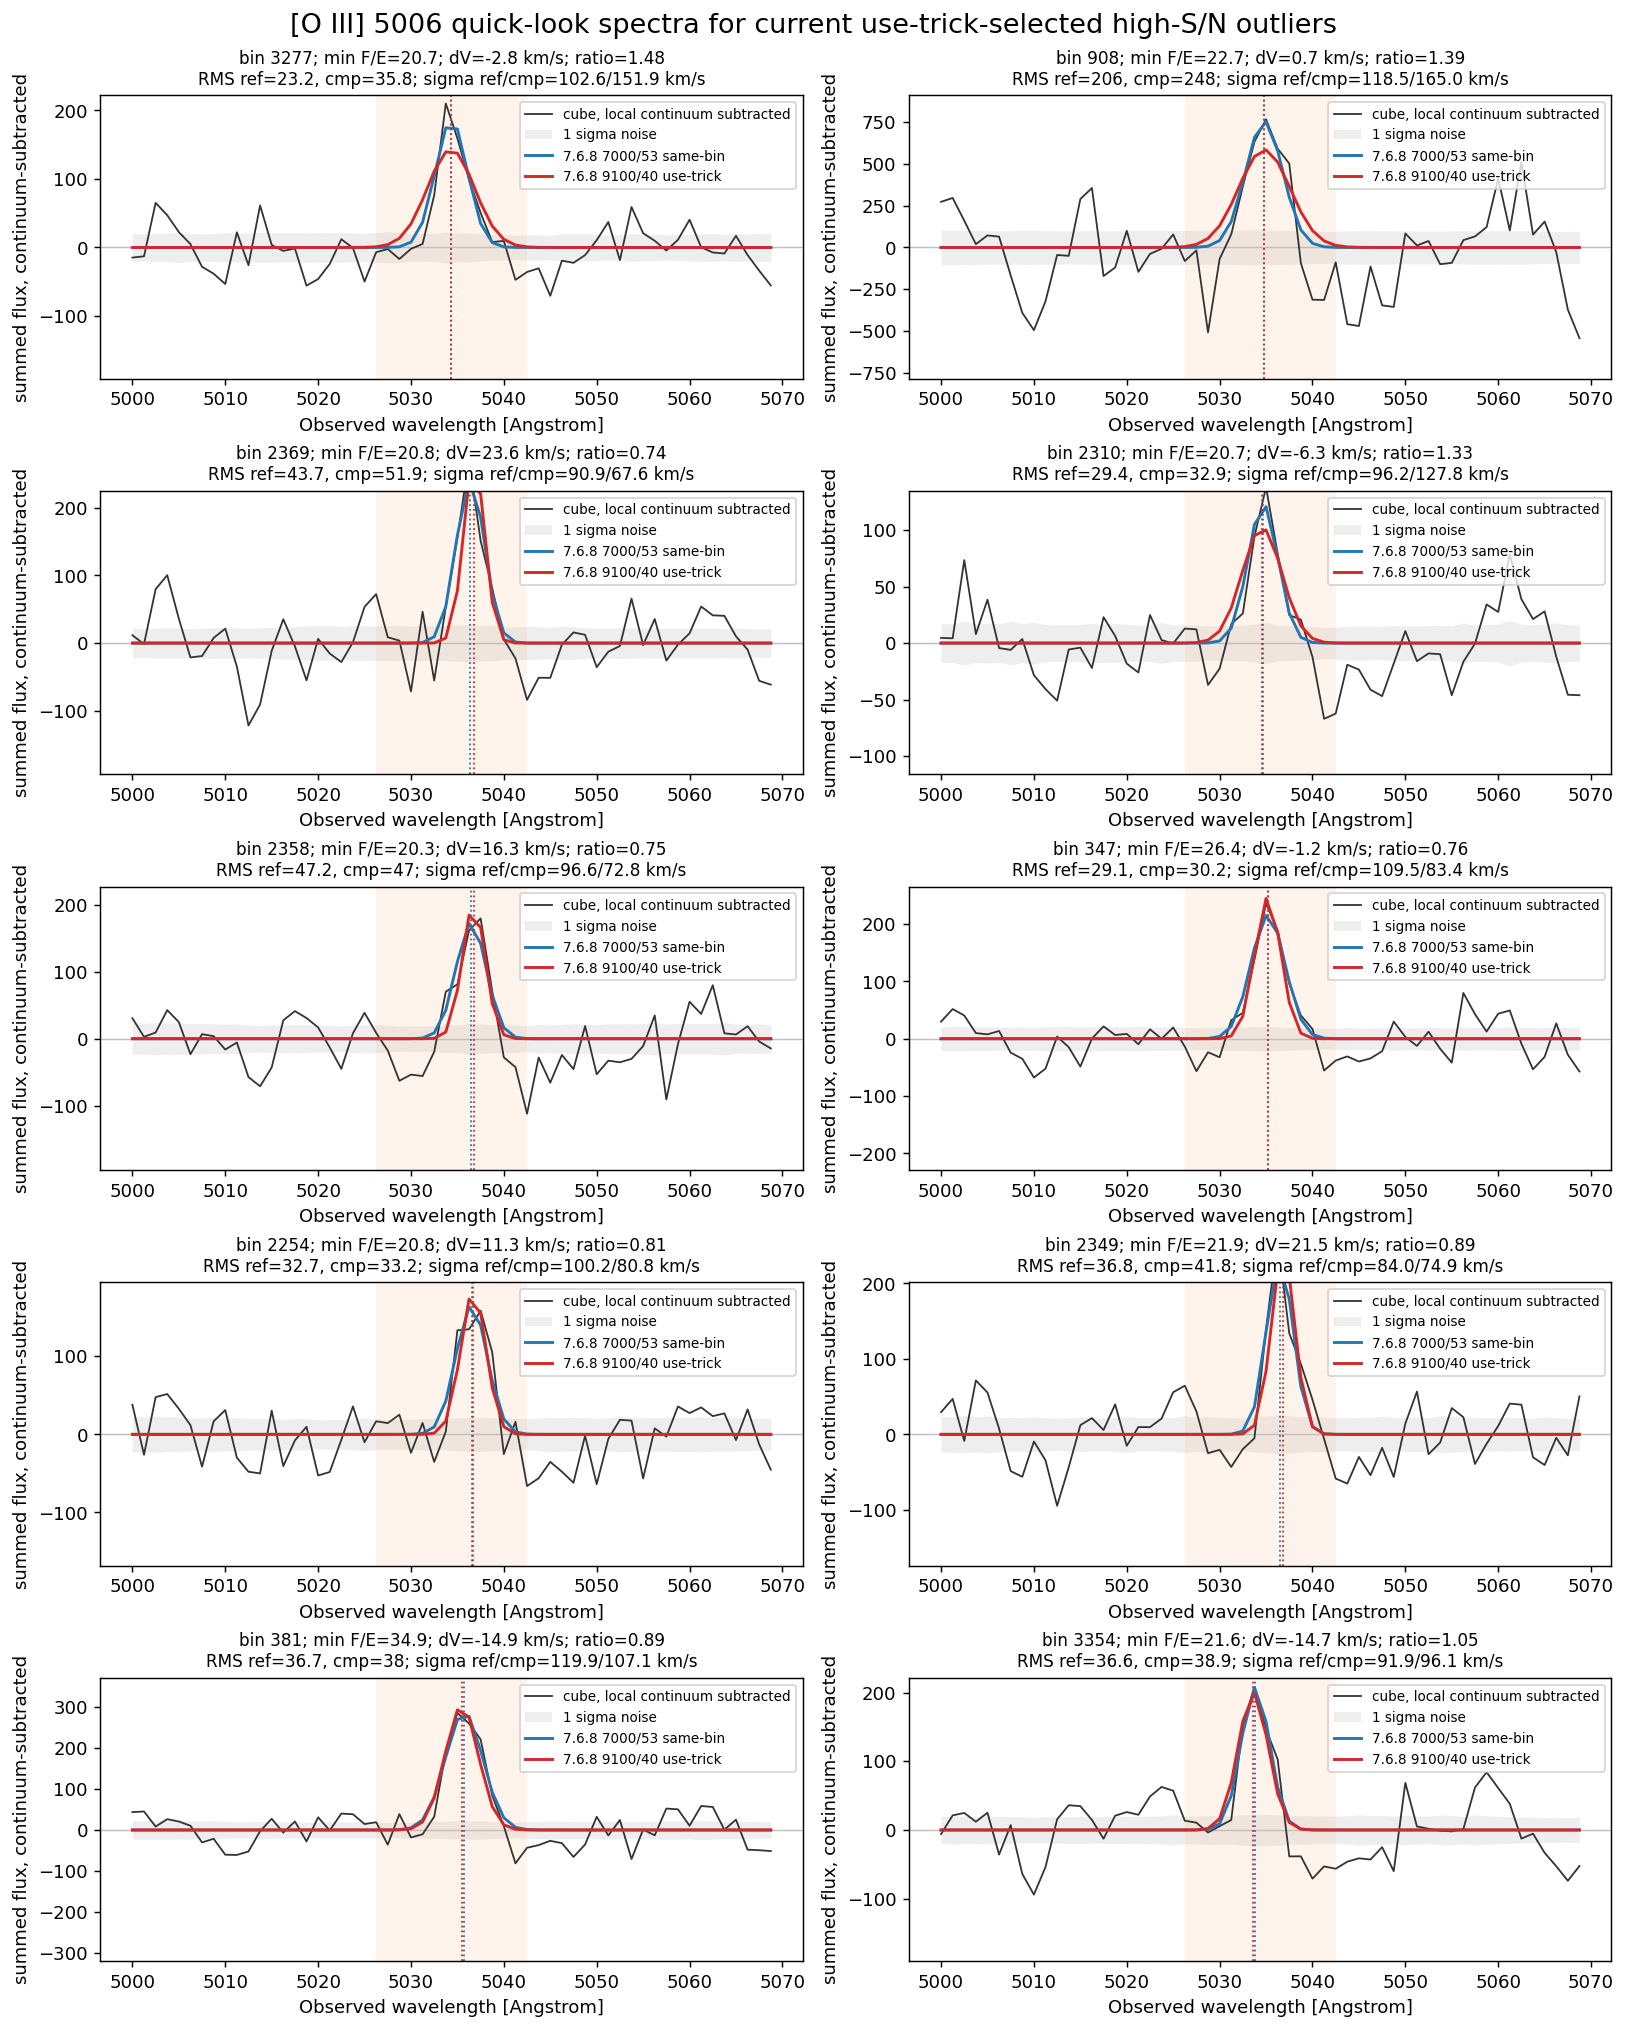

In [10]:
def plot_selected_spectra(spectra):
    if not spectra:
        print('No spectra to plot.')
        return
    n = len(spectra)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12.4, 3.1 * nrows), squeeze=False, constrained_layout=True)
    fig.suptitle(f'{OIII_LABEL} quick-look spectra for current use-trick-selected high-S/N outliers', fontsize=15)

    for ax, spec in zip(axes.ravel(), spectra):
        row = spec['row']
        wave = spec['wave']
        contsub = spec['contsub']
        ref_fit = spec['ref_fit']
        cmp_fit = spec['cmp_fit']
        line_window = spec['line_window']
        finite_contsub = contsub[np.isfinite(contsub)]
        y_scale = np.nanpercentile(np.abs(finite_contsub), 98) if finite_contsub.size else 1.0
        y_scale = y_scale if np.isfinite(y_scale) and y_scale > 0 else 1.0

        ax.axhline(0, color='0.75', linewidth=0.8)
        ax.plot(wave, contsub, color='0.2', linewidth=1.0, label='cube, local continuum subtracted')
        if np.isfinite(spec['noise']).any():
            ax.fill_between(wave, -spec['noise'], spec['noise'], color='0.7', alpha=0.22, linewidth=0, label='1 sigma noise')
        ax.plot(wave, ref_fit['model'], color=RUNS[BASELINE_RUN]['color'], linewidth=1.6, label=RUNS[BASELINE_RUN]['plot_label'])
        ax.plot(wave, cmp_fit['model'], color=RUNS[COMPARE_RUN]['color'], linewidth=1.6, label=RUNS[COMPARE_RUN]['plot_label'])
        ax.axvspan(wave[line_window].min(), wave[line_window].max(), color='tab:orange', alpha=0.08, linewidth=0)
        ax.axvline(ref_fit['center'], color=RUNS[BASELINE_RUN]['color'], linestyle=':', linewidth=1)
        ax.axvline(cmp_fit['center'], color=RUNS[COMPARE_RUN]['color'], linestyle=':', linewidth=1)

        title = (
            f'bin {int(row["bin_id"])}; min F/E={row["both_fluxerr_min"]:.1f}; '
            f'dV={row["delta_vel"]:.1f} km/s; ratio={row["sigma_ratio"]:.2f}'
        )
        subtitle = (
            f'RMS ref={ref_fit["rms"]:.3g}, cmp={cmp_fit["rms"]:.3g}; '
            f'sigma ref/cmp={row["ref_sigma"]:.1f}/{row["cmp_sigma"]:.1f} km/s'
        )
        ax.set_title(title + '\n' + subtitle, fontsize=9.3)
        ax.set_xlabel('Observed wavelength [Angstrom]')
        ax.set_ylabel('summed flux, continuum-subtracted')
        ax.set_ylim(-1.25 * y_scale, 1.45 * y_scale)
        ax.legend(loc='upper right', fontsize=7.5, frameon=True)

    for ax in axes.ravel()[len(spectra):]:
        ax.axis('off')
    plt.show()


plot_selected_spectra(selected_spectra)


## Previous Full-Line Selected Bins Rechecked With Use-Trick Run

The section above asks: what are the most suspicious bins after the `use-trick` rerun?

This section asks the complementary question: what happened to the exact 10 bins that were suspicious in the previous full-line `9100/40` notebook? Those fixed bin IDs are:

`908, 3277, 2369, 347, 2358, 2310, 2254, 381, 2349, 3354`

The next cells redo the pairwise diagnostics and the OIII quick-look spectra for that fixed old-selection list, but with the current `9100/40 use-trick` comparison values and Gaussian overlays.

In [11]:
PREVIOUS_FULL_LINE_SELECTED_BINS = [
    ('large sigma ratio', 908),
    ('large sigma ratio', 3277),
    ('large sigma ratio', 2369),
    ('large sigma ratio', 347),
    ('large sigma ratio', 2358),
    ('large sigma ratio', 2310),
    ('large velocity difference', 2254),
    ('large velocity difference', 381),
    ('large velocity difference', 2349),
    ('large velocity difference', 3354),
]

previous_bin_order = [bin_id for _, bin_id in PREVIOUS_FULL_LINE_SELECTED_BINS]
previous_reason_by_bin = {bin_id: reason for reason, bin_id in PREVIOUS_FULL_LINE_SELECTED_BINS}
previous_full_line_selected_bins = (
    bin_table[bin_table['bin_id'].isin(previous_bin_order)]
    .copy()
    .assign(
        previous_full_line_selection_reason=lambda df: df['bin_id'].map(previous_reason_by_bin),
        previous_full_line_order=lambda df: df['bin_id'].map({bin_id: i for i, bin_id in enumerate(previous_bin_order)}),
    )
    .sort_values('previous_full_line_order')
    .reset_index(drop=True)
)

missing_previous_bins = [bin_id for bin_id in previous_bin_order if bin_id not in set(previous_full_line_selected_bins['bin_id'])]
if missing_previous_bins:
    print('Warning: missing previous full-line selected bins in current bin table:', missing_previous_bins)

previous_display_cols = [
    'previous_full_line_selection_reason', 'bin_id', 'row', 'col', 'n_spaxels', 'both_fluxerr_min',
    'ref_fluxerr', 'cmp_fluxerr', 'delta_vel', 'abs_delta_vel',
    'delta_sigma', 'abs_delta_sigma', 'sigma_ratio', 'log10_sigma_ratio',
    'ref_vel', 'cmp_vel', 'ref_sigma', 'cmp_sigma',
]
display(previous_full_line_selected_bins[previous_display_cols])
print(f'Previous full-line selected bins recovered here: {len(previous_full_line_selected_bins):,}')


,previous_full_line_selection_reason,bin_id,row,col,n_spaxels,both_fluxerr_min,ref_fluxerr,cmp_fluxerr,delta_vel,abs_delta_vel,delta_sigma,abs_delta_sigma,sigma_ratio,log10_sigma_ratio,ref_vel,cmp_vel,ref_sigma,cmp_sigma
0,large sigma ratio,908,87.0,187.0,451,22.660587,22.660587,23.426256,0.680095,0.680095,46.513475,46.513475,1.392603,0.143827,4.913349,5.593444,118.474543,164.988019
1,large sigma ratio,3277,200.0,292.0,8,20.713541,20.713541,20.840936,-2.793866,2.793866,49.236136,49.236136,1.479786,0.170199,-21.449641,-24.243507,102.621033,151.857170
2,large sigma ratio,2369,304.0,162.0,16,20.805057,22.320831,20.805057,23.610582,23.610582,-23.341800,23.341800,0.743223,-0.128881,100.166363,123.776945,90.903007,67.561208
3,large sigma ratio,347,195.0,213.0,11,26.351823,26.576036,26.351823,-1.151883,1.151883,-26.091676,26.091676,0.761710,-0.118210,29.486577,28.334694,109.495352,83.403676
4,large sigma ratio,2358,297.5,192.0,10,20.273606,21.097449,20.273606,16.344419,16.344419,-23.733490,23.733490,0.754240,-0.122491,104.934936,121.279355,96.571649,72.838159
5,large sigma ratio,2310,229.5,256.5,4,20.717998,20.820768,20.717998,-6.264355,6.264355,31.556958,31.556958,1.327945,0.123180,-2.560149,-8.824504,96.226285,127.783243
6,large velocity difference,2254,296.0,190.0,9,20.819538,21.201866,20.819538,11.348891,11.348891,-19.395025,19.395025,0.806384,-0.093458,107.904101,119.252992,100.172819,80.777793
7,large velocity difference,381,193.0,211.0,11,34.876029,35.873955,34.876029,-14.933557,14.933557,-12.755271,12.755271,0.893577,-0.048868,59.726059,44.792501,119.854143,107.098872
8,large velocity difference,2349,298.5,188.0,10,21.927822,22.075691,21.927822,21.450538,21.450538,-9.107714,9.107714,0.891533,-0.049863,104.666720,126.117258,83.967301,74.859587
9,large velocity difference,3354,164.0,284.0,9,21.644525,22.233704,21.644525,-14.696608,14.696608,4.268911,4.268911,1.046468,0.019726,-50.901795,-65.598404,91.868532,96.137444


Previous full-line selected bins recovered here: 10


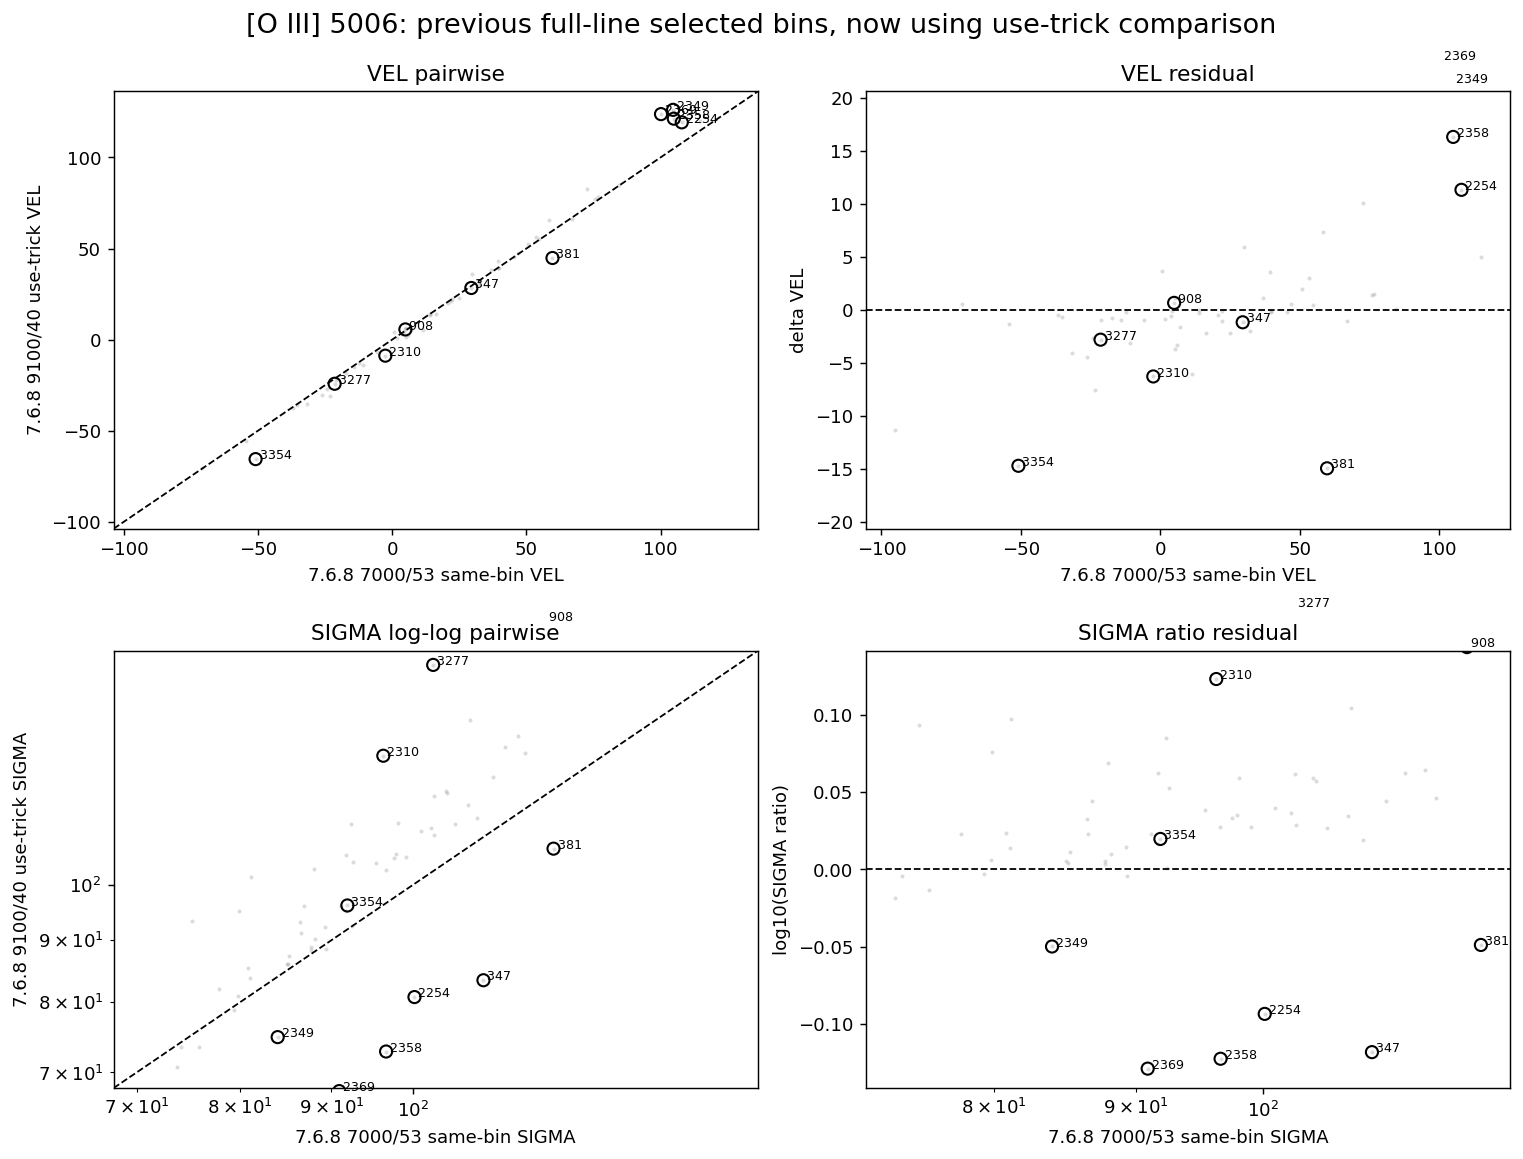

In [12]:
def scatter_highlight_bins(ax, highlight_bins, x_col, y_col, color='black', label_col='bin_id'):
    ax.scatter(highlight_bins[x_col], highlight_bins[y_col], s=45, facecolors='none', edgecolors=color, linewidths=1.15, zorder=5)
    for _, row in highlight_bins.iterrows():
        ax.text(row[x_col], row[y_col], f' {int(row[label_col])}', fontsize=7, color=color, zorder=6)


fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.8), constrained_layout=True)
fig.suptitle(f'{OIII_LABEL}: previous full-line selected bins, now using use-trick comparison', fontsize=15)

plot_sample = high_snr.copy()
if len(plot_sample) > 25000:
    plot_sample = plot_sample.sample(25000, random_state=12)

ax = axes[0, 0]
lo, hi = robust_limits(high_snr[['ref_vel', 'cmp_vel']].to_numpy().ravel(), p=(1, 99), fallback=(-150, 150))
ax.scatter(plot_sample['ref_vel'], plot_sample['cmp_vel'], s=5, alpha=0.25, linewidths=0, color='0.45')
ax.plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=1)
scatter_highlight_bins(ax, previous_full_line_selected_bins, 'ref_vel', 'cmp_vel')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} VEL')
ax.set_ylabel(f'{RUNS[COMPARE_RUN]["plot_label"]} VEL')
ax.set_title('VEL pairwise')

ax = axes[0, 1]
vel_lim = symmetric_limit(high_snr['delta_vel'], 98, 25)
ax.scatter(plot_sample['ref_vel'], plot_sample['delta_vel'], s=5, alpha=0.25, linewidths=0, color='0.45')
scatter_highlight_bins(ax, previous_full_line_selected_bins, 'ref_vel', 'delta_vel')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_ylim(-vel_lim, vel_lim)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} VEL')
ax.set_ylabel('delta VEL')
ax.set_title('VEL residual')

ax = axes[1, 0]
sigma_values = high_snr[['ref_sigma', 'cmp_sigma']].to_numpy().ravel()
sigma_values = sigma_values[np.isfinite(sigma_values) & (sigma_values > 0)]
slo_log, shi_log = robust_limits(np.log10(sigma_values), p=(1, 99), fallback=(np.log10(30), np.log10(400)))
slo, shi = 10**slo_log, 10**shi_log
ax.scatter(plot_sample['ref_sigma'], plot_sample['cmp_sigma'], s=5, alpha=0.25, linewidths=0, color='0.45')
ax.plot([slo, shi], [slo, shi], color='black', linestyle='--', linewidth=1)
scatter_highlight_bins(ax, previous_full_line_selected_bins, 'ref_sigma', 'cmp_sigma')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(slo, shi)
ax.set_ylim(slo, shi)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} SIGMA')
ax.set_ylabel(f'{RUNS[COMPARE_RUN]["plot_label"]} SIGMA')
ax.set_title('SIGMA log-log pairwise')

ax = axes[1, 1]
log_lim = symmetric_limit(high_snr['log10_sigma_ratio'], 98, 0.3)
ax.scatter(plot_sample['ref_sigma'], plot_sample['log10_sigma_ratio'], s=5, alpha=0.25, linewidths=0, color='0.45')
scatter_highlight_bins(ax, previous_full_line_selected_bins, 'ref_sigma', 'log10_sigma_ratio')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_ylim(-log_lim, log_lim)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} SIGMA')
ax.set_ylabel('log10(SIGMA ratio)')
ax.set_title('SIGMA ratio residual')

plt.show()


Extracted spectra for 10 previous full-line selected bins.


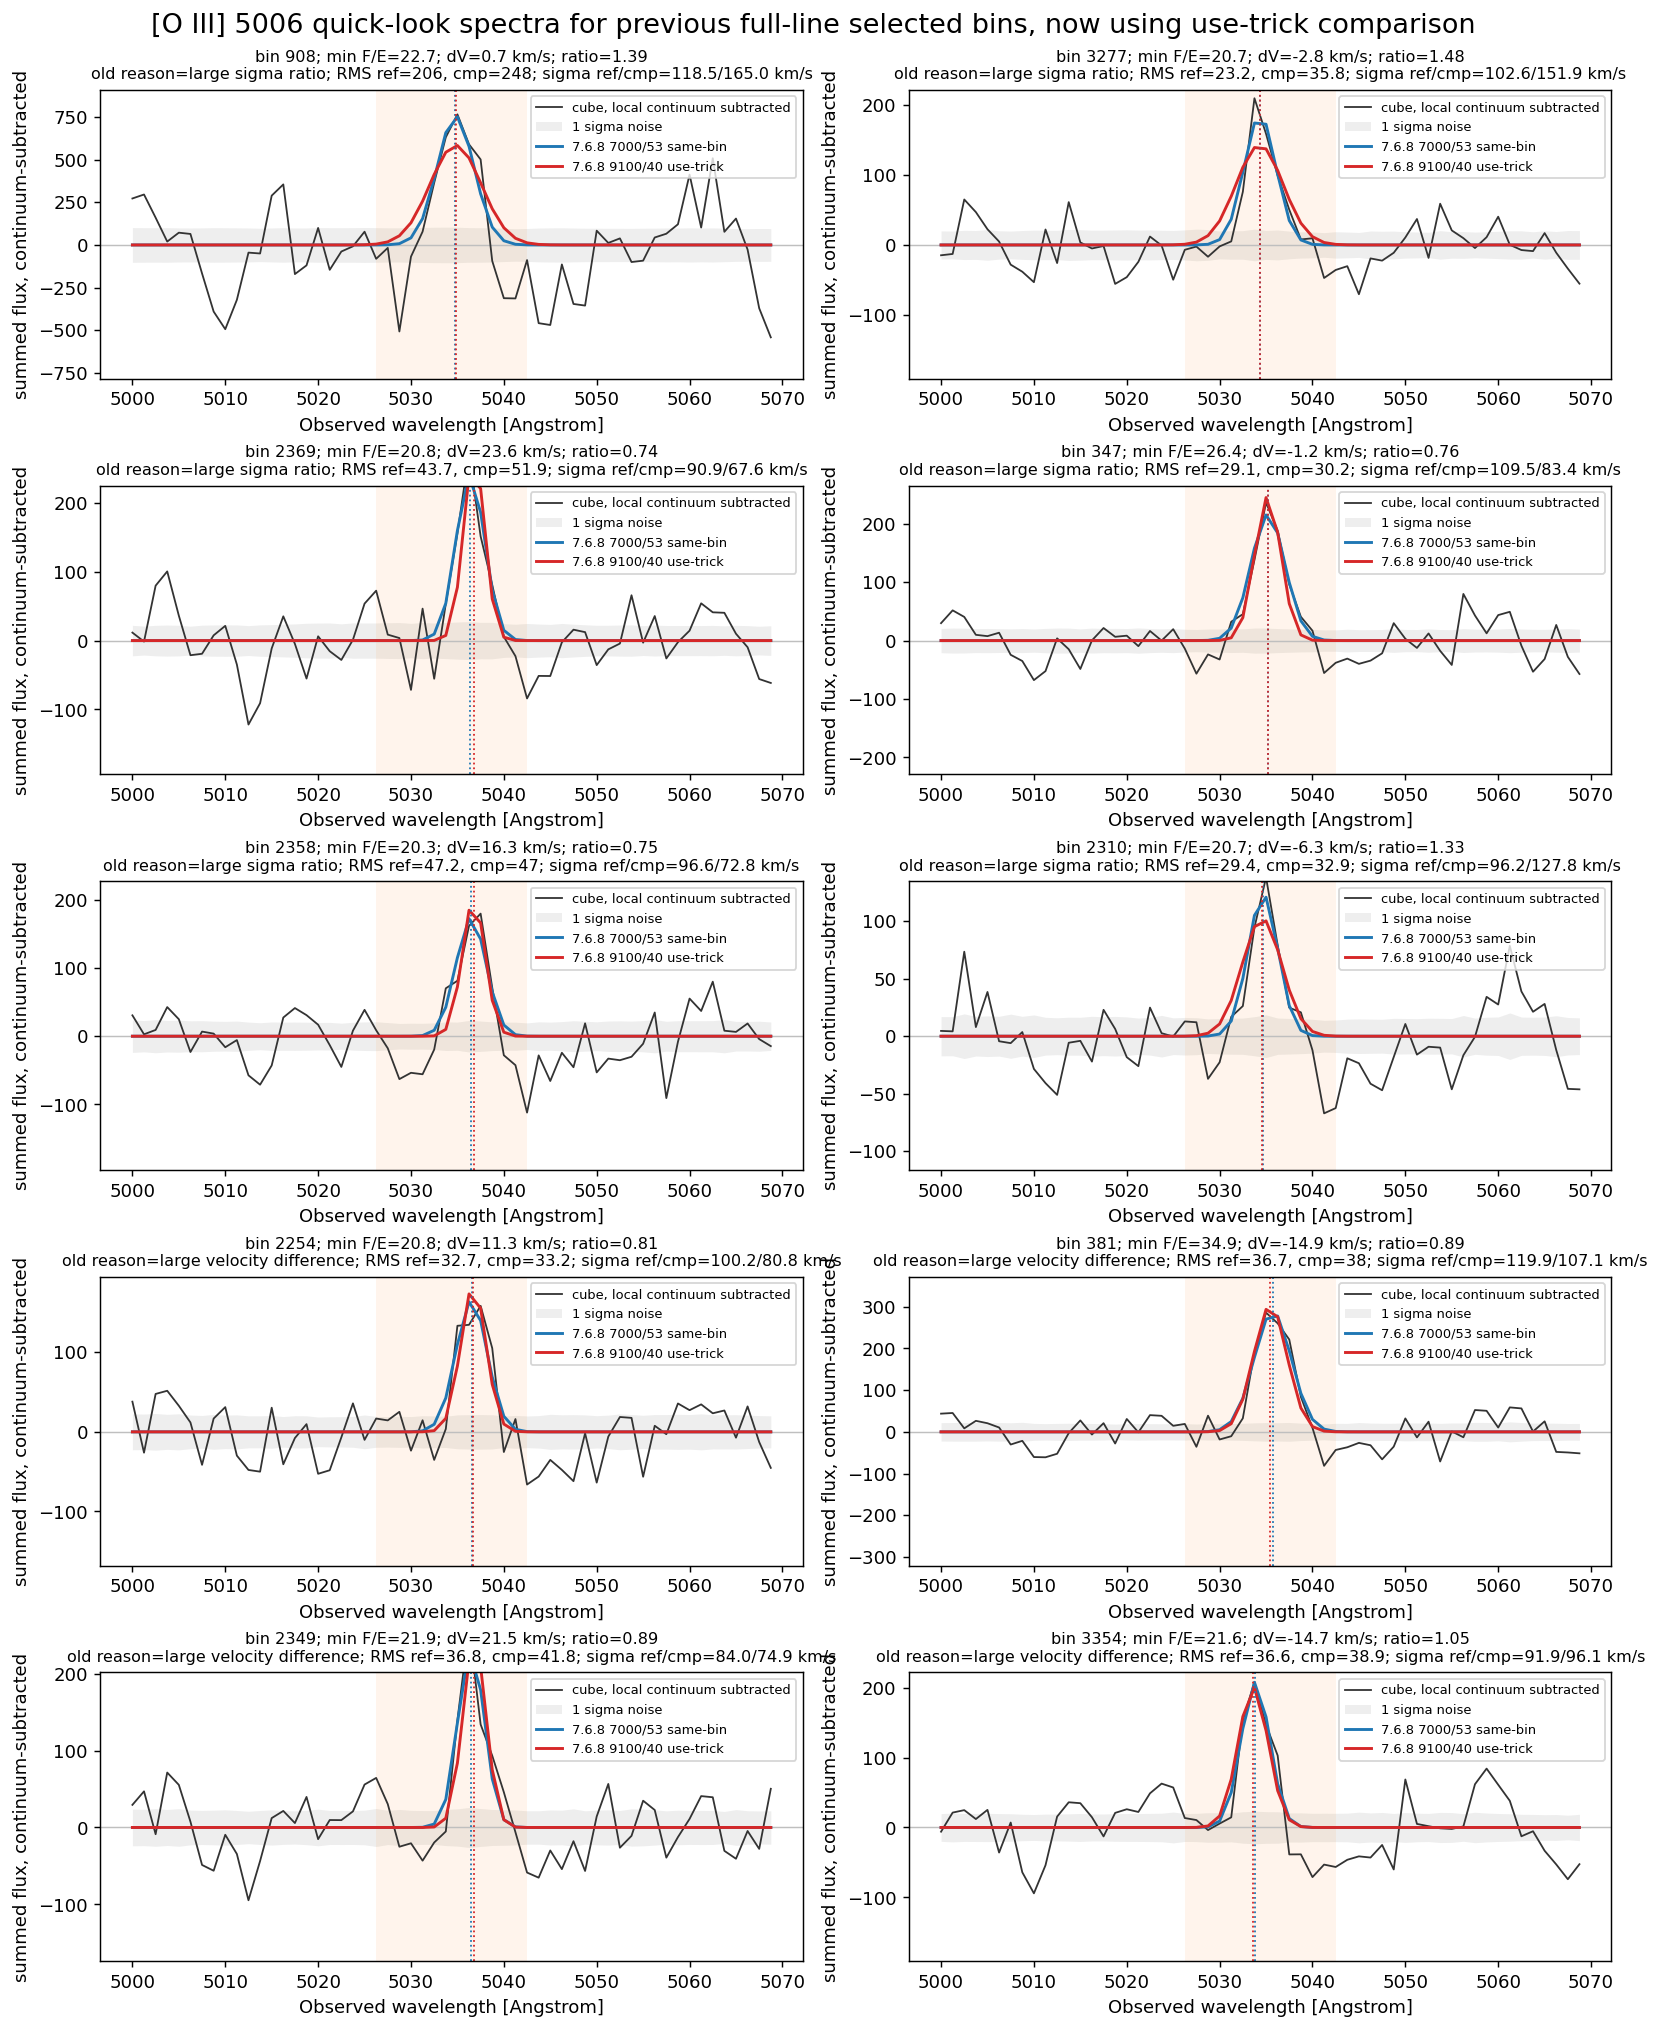

In [13]:
previous_full_line_spectra = extract_selected_bin_spectra(previous_full_line_selected_bins.head(N_SPECTRA_TO_PLOT).copy())
print(f'Extracted spectra for {len(previous_full_line_spectra)} previous full-line selected bins.')


def plot_previous_full_line_spectra(spectra):
    if not spectra:
        print('No previous full-line spectra to plot.')
        return
    n = len(spectra)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12.4, 3.1 * nrows), squeeze=False, constrained_layout=True)
    fig.suptitle(f'{OIII_LABEL} quick-look spectra for previous full-line selected bins, now using use-trick comparison', fontsize=15)

    for ax, spec in zip(axes.ravel(), spectra):
        row = spec['row']
        wave = spec['wave']
        contsub = spec['contsub']
        ref_fit = spec['ref_fit']
        cmp_fit = spec['cmp_fit']
        line_window = spec['line_window']
        finite_contsub = contsub[np.isfinite(contsub)]
        y_scale = np.nanpercentile(np.abs(finite_contsub), 98) if finite_contsub.size else 1.0
        y_scale = y_scale if np.isfinite(y_scale) and y_scale > 0 else 1.0

        ax.axhline(0, color='0.75', linewidth=0.8)
        ax.plot(wave, contsub, color='0.2', linewidth=1.0, label='cube, local continuum subtracted')
        if np.isfinite(spec['noise']).any():
            ax.fill_between(wave, -spec['noise'], spec['noise'], color='0.7', alpha=0.22, linewidth=0, label='1 sigma noise')
        ax.plot(wave, ref_fit['model'], color=RUNS[BASELINE_RUN]['color'], linewidth=1.6, label=RUNS[BASELINE_RUN]['plot_label'])
        ax.plot(wave, cmp_fit['model'], color=RUNS[COMPARE_RUN]['color'], linewidth=1.6, label=RUNS[COMPARE_RUN]['plot_label'])
        ax.axvspan(wave[line_window].min(), wave[line_window].max(), color='tab:orange', alpha=0.08, linewidth=0)
        ax.axvline(ref_fit['center'], color=RUNS[BASELINE_RUN]['color'], linestyle=':', linewidth=1)
        ax.axvline(cmp_fit['center'], color=RUNS[COMPARE_RUN]['color'], linestyle=':', linewidth=1)

        title = (
            f'bin {int(row["bin_id"])}; min F/E={row["both_fluxerr_min"]:.1f}; '
            f'dV={row["delta_vel"]:.1f} km/s; ratio={row["sigma_ratio"]:.2f}'
        )
        subtitle = (
            f'old reason={row["previous_full_line_selection_reason"]}; '
            f'RMS ref={ref_fit["rms"]:.3g}, cmp={cmp_fit["rms"]:.3g}; '
            f'sigma ref/cmp={row["ref_sigma"]:.1f}/{row["cmp_sigma"]:.1f} km/s'
        )
        ax.set_title(title + '\n' + subtitle, fontsize=8.9)
        ax.set_xlabel('Observed wavelength [Angstrom]')
        ax.set_ylabel('summed flux, continuum-subtracted')
        ax.set_ylim(-1.25 * y_scale, 1.45 * y_scale)
        ax.legend(loc='upper right', fontsize=7.2, frameon=True)

    for ax in axes.ravel()[len(spectra):]:
        ax.axis('off')
    plt.show()


plot_previous_full_line_spectra(previous_full_line_spectra)


## SIII Quick-Look Spectra For Current And Previous Selected Bins

The OIII panels above only test the line used for the outlier ranking. This section repeats the same local-cube quick-look for `SIII6312` and `SIII9068`, using both selected-bin sets:

- the current 10 bins selected from the `9100/40 use-trick` comparison.
- the previous 10 bins selected in the full-line `9100/40` notebook, rechecked here with the current use-trick maps.

For each sulfur line, the cube spectrum is summed over the same `BIN_ID`, locally continuum-subtracted, and overlaid with any available GAS-map Gaussian model. The model normalization uses the GAS-map line `FLUX` multiplied by the number of spaxels in the bin, so it is on the same summed-bin scale as the plotted cube spectrum. If the 7000/53 reference has no finite map for a sulfur line, only the use-trick comparison model is shown.


,line_id,line_label,rest_air_a,active_fit,mode,has_extensions_ref,finite_flux_pixels_ref,available_ref,has_extensions_cmp,finite_flux_pixels_cmp,available_cmp,available_runs,missing_ref,missing_cmp
0,SIII6312,SIII 6312,6312.06,True,k17,False,0,False,True,94543,True,7.6.8 9100/40 use-trick,"SIII6312_FLUX, SIII6312_FLUX_ERR, SIII6312_VEL, SIII6312_VEL_ERR, SIII6312_SIGMA, SIII6312_SIGMA_ERR, SIII6312_SIGMA_CORR",
1,SIII9068,SIII 9068,9068.60,True,k23,False,0,False,True,94543,True,7.6.8 9100/40 use-trick,"SIII9068_FLUX, SIII9068_FLUX_ERR, SIII9068_VEL, SIII9068_VEL_ERR, SIII9068_SIGMA, SIII9068_SIGMA_ERR, SIII9068_SIGMA_CORR",


Requested SIII lines found in use-trick config: 2
Model-plottable in at least one GAS map: 2


,selection_label,line_id,bin_id,selection_reason,oiii_min_fluxerr,oiii_delta_vel,oiii_sigma_ratio,ref_available,ref_line_fluxerr,ref_line_minus_oiii_vel,ref_line_minus_oiii_sigma,cmp_available,cmp_line_fluxerr,cmp_line_minus_oiii_vel,cmp_line_minus_oiii_sigma
0,current use-trick-selected bins,SIII6312,3277,large sigma ratio,20.713541,-2.793866,1.479786,False,NaN,NaN,NaN,True,0.942886,0.0,-5.056516
1,current use-trick-selected bins,SIII6312,908,large sigma ratio,22.660587,0.680095,1.392603,False,NaN,NaN,NaN,True,4.701421,0.0,-4.641899
2,current use-trick-selected bins,SIII6312,2369,large sigma ratio; large velocity difference,20.805057,23.610582,0.743223,False,NaN,NaN,NaN,True,6.726764,0.0,-12.295046
3,current use-trick-selected bins,SIII6312,2310,large sigma ratio,20.717998,-6.264355,1.327945,False,NaN,NaN,NaN,True,0.000000,0.0,-6.052437
4,current use-trick-selected bins,SIII6312,2358,large sigma ratio; large velocity difference,20.273606,16.344419,0.754240,False,NaN,NaN,NaN,True,5.354174,0.0,-11.232727
5,current use-trick-selected bins,SIII6312,347,large sigma ratio,26.351823,-1.151883,0.761710,False,NaN,NaN,NaN,True,0.626201,0.0,-9.606623
6,current use-trick-selected bins,SIII6312,2254,large velocity difference,20.819538,11.348891,0.806384,False,NaN,NaN,NaN,True,0.000000,0.0,-9.961949
7,current use-trick-selected bins,SIII6312,2349,large velocity difference,21.927822,21.450538,0.891533,False,NaN,NaN,NaN,True,0.000000,0.0,-10.876858
8,current use-trick-selected bins,SIII6312,381,large velocity difference,34.876029,-14.933557,0.893577,False,NaN,NaN,NaN,True,0.000000,0.0,-7.299071
9,current use-trick-selected bins,SIII6312,3354,large velocity difference,21.644525,-14.696608,1.046468,False,NaN,NaN,NaN,True,0.000000,0.0,-8.204288


Extracted 10 spectra for SIII 6312 in current use-trick-selected bins; model runs: 7.6.8 9100/40 use-trick.


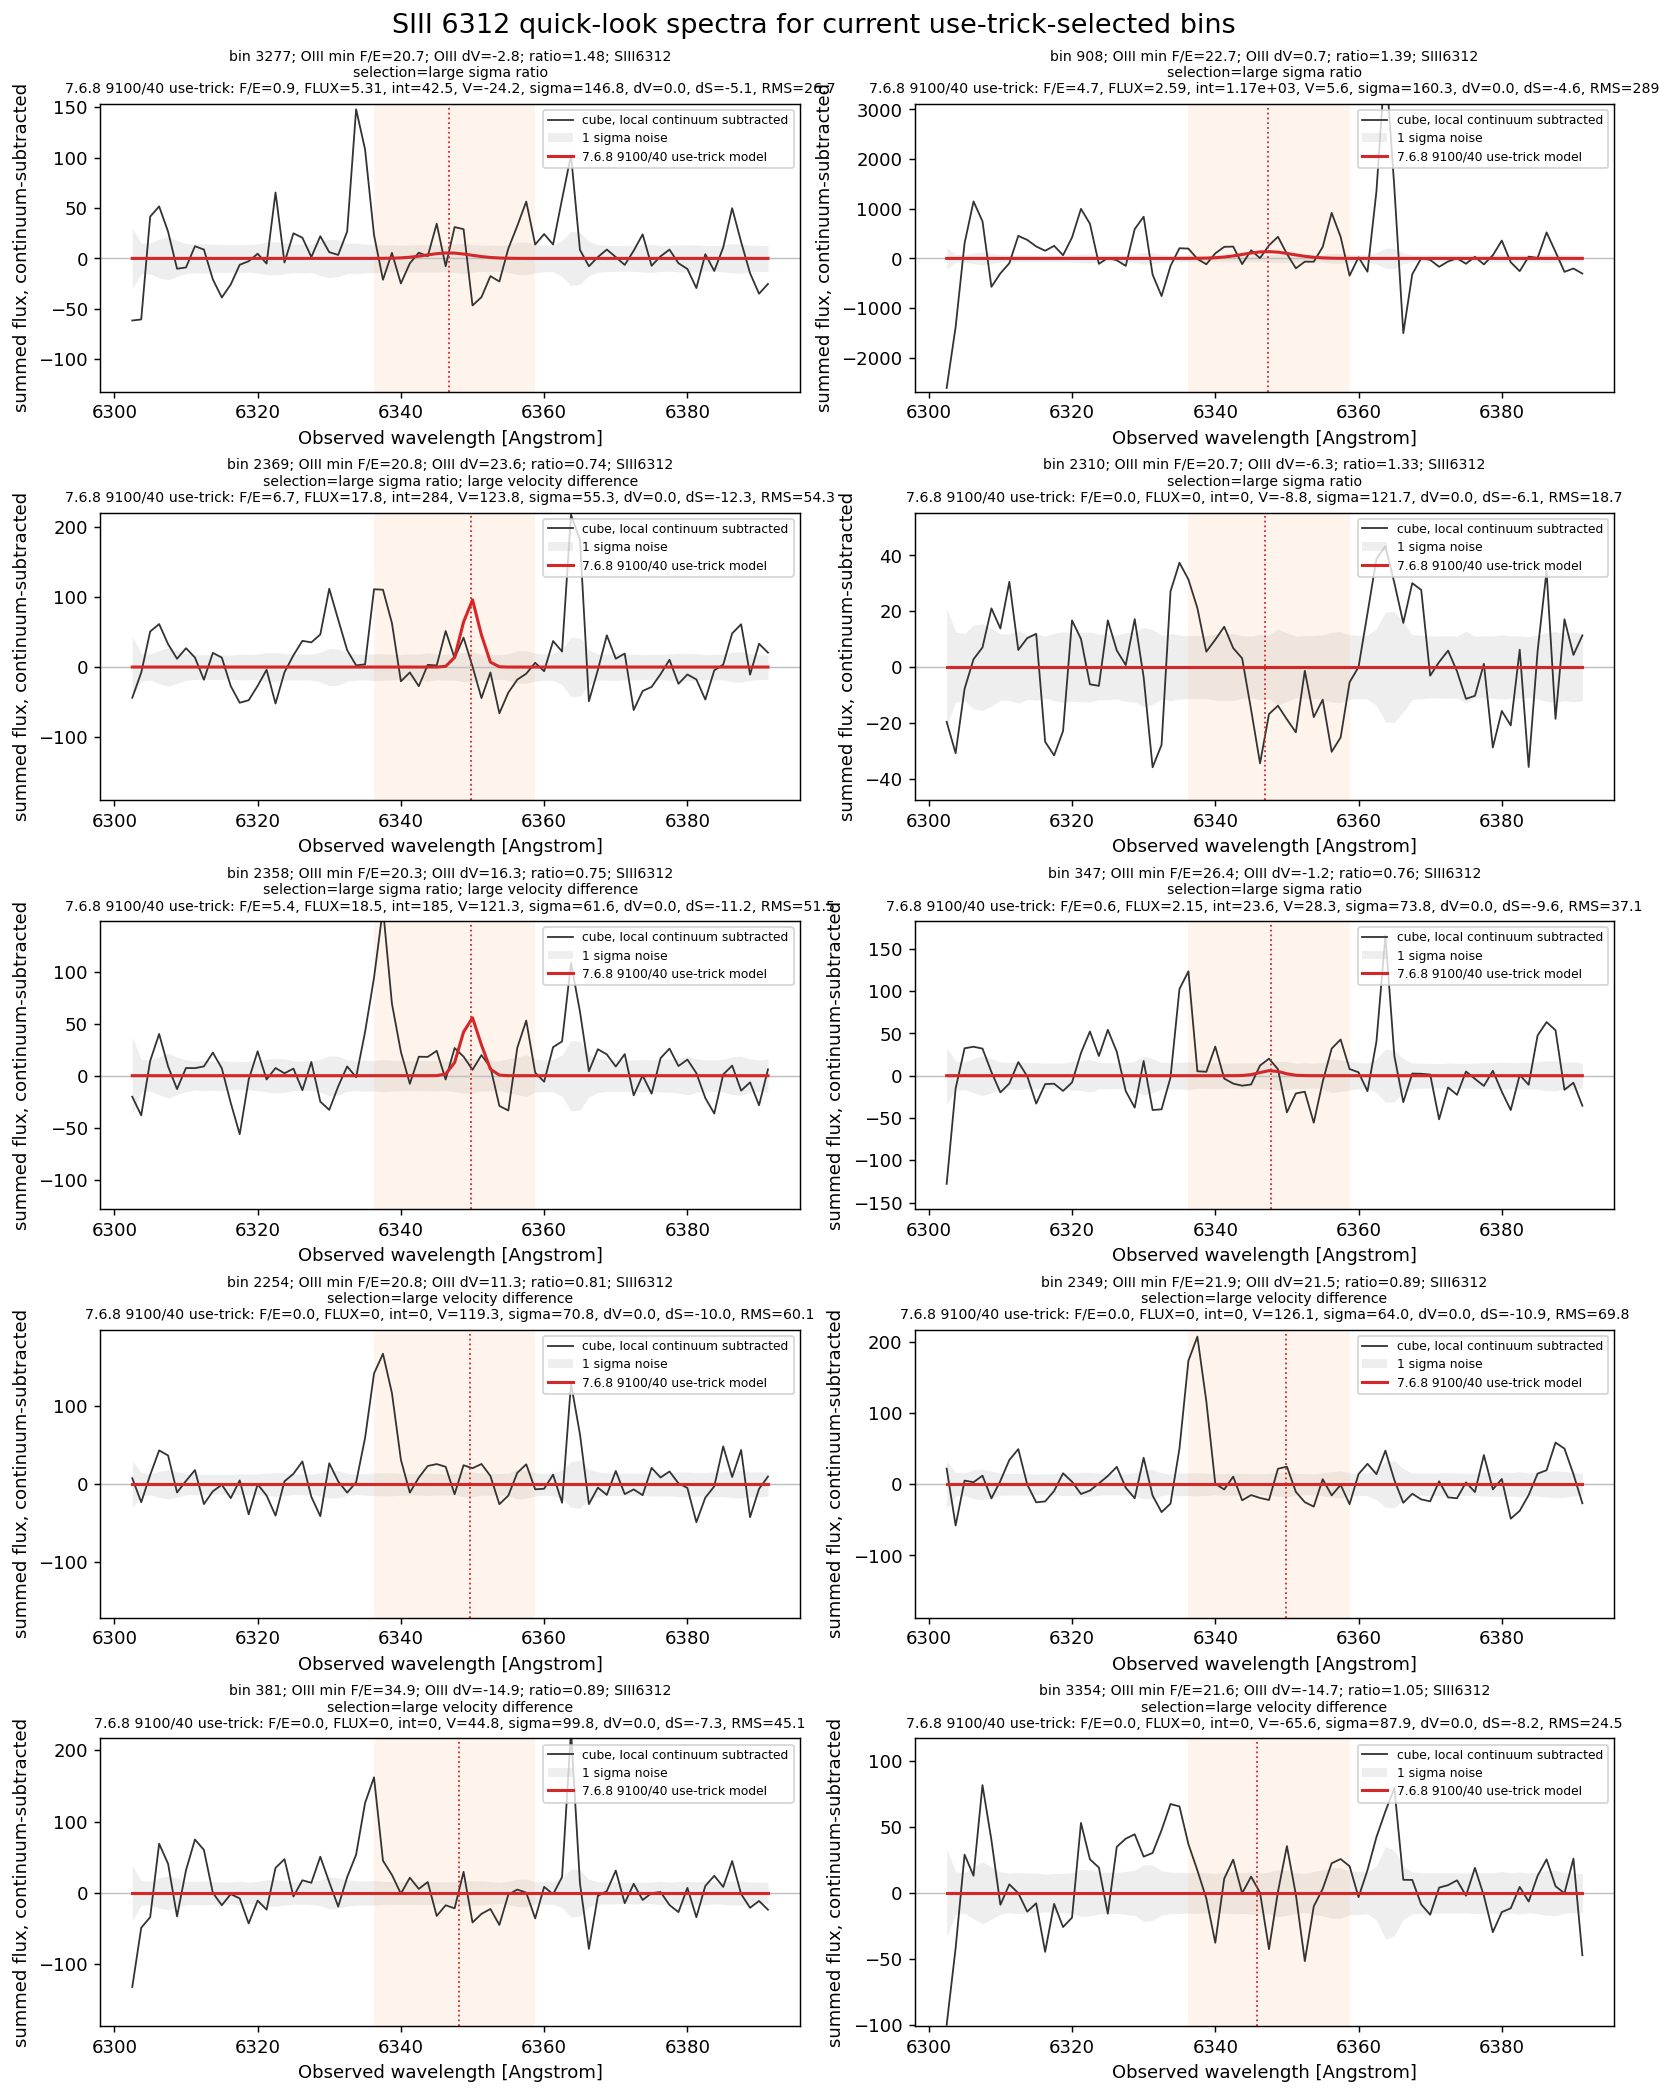

Extracted 10 spectra for SIII 9068 in current use-trick-selected bins; model runs: 7.6.8 9100/40 use-trick.


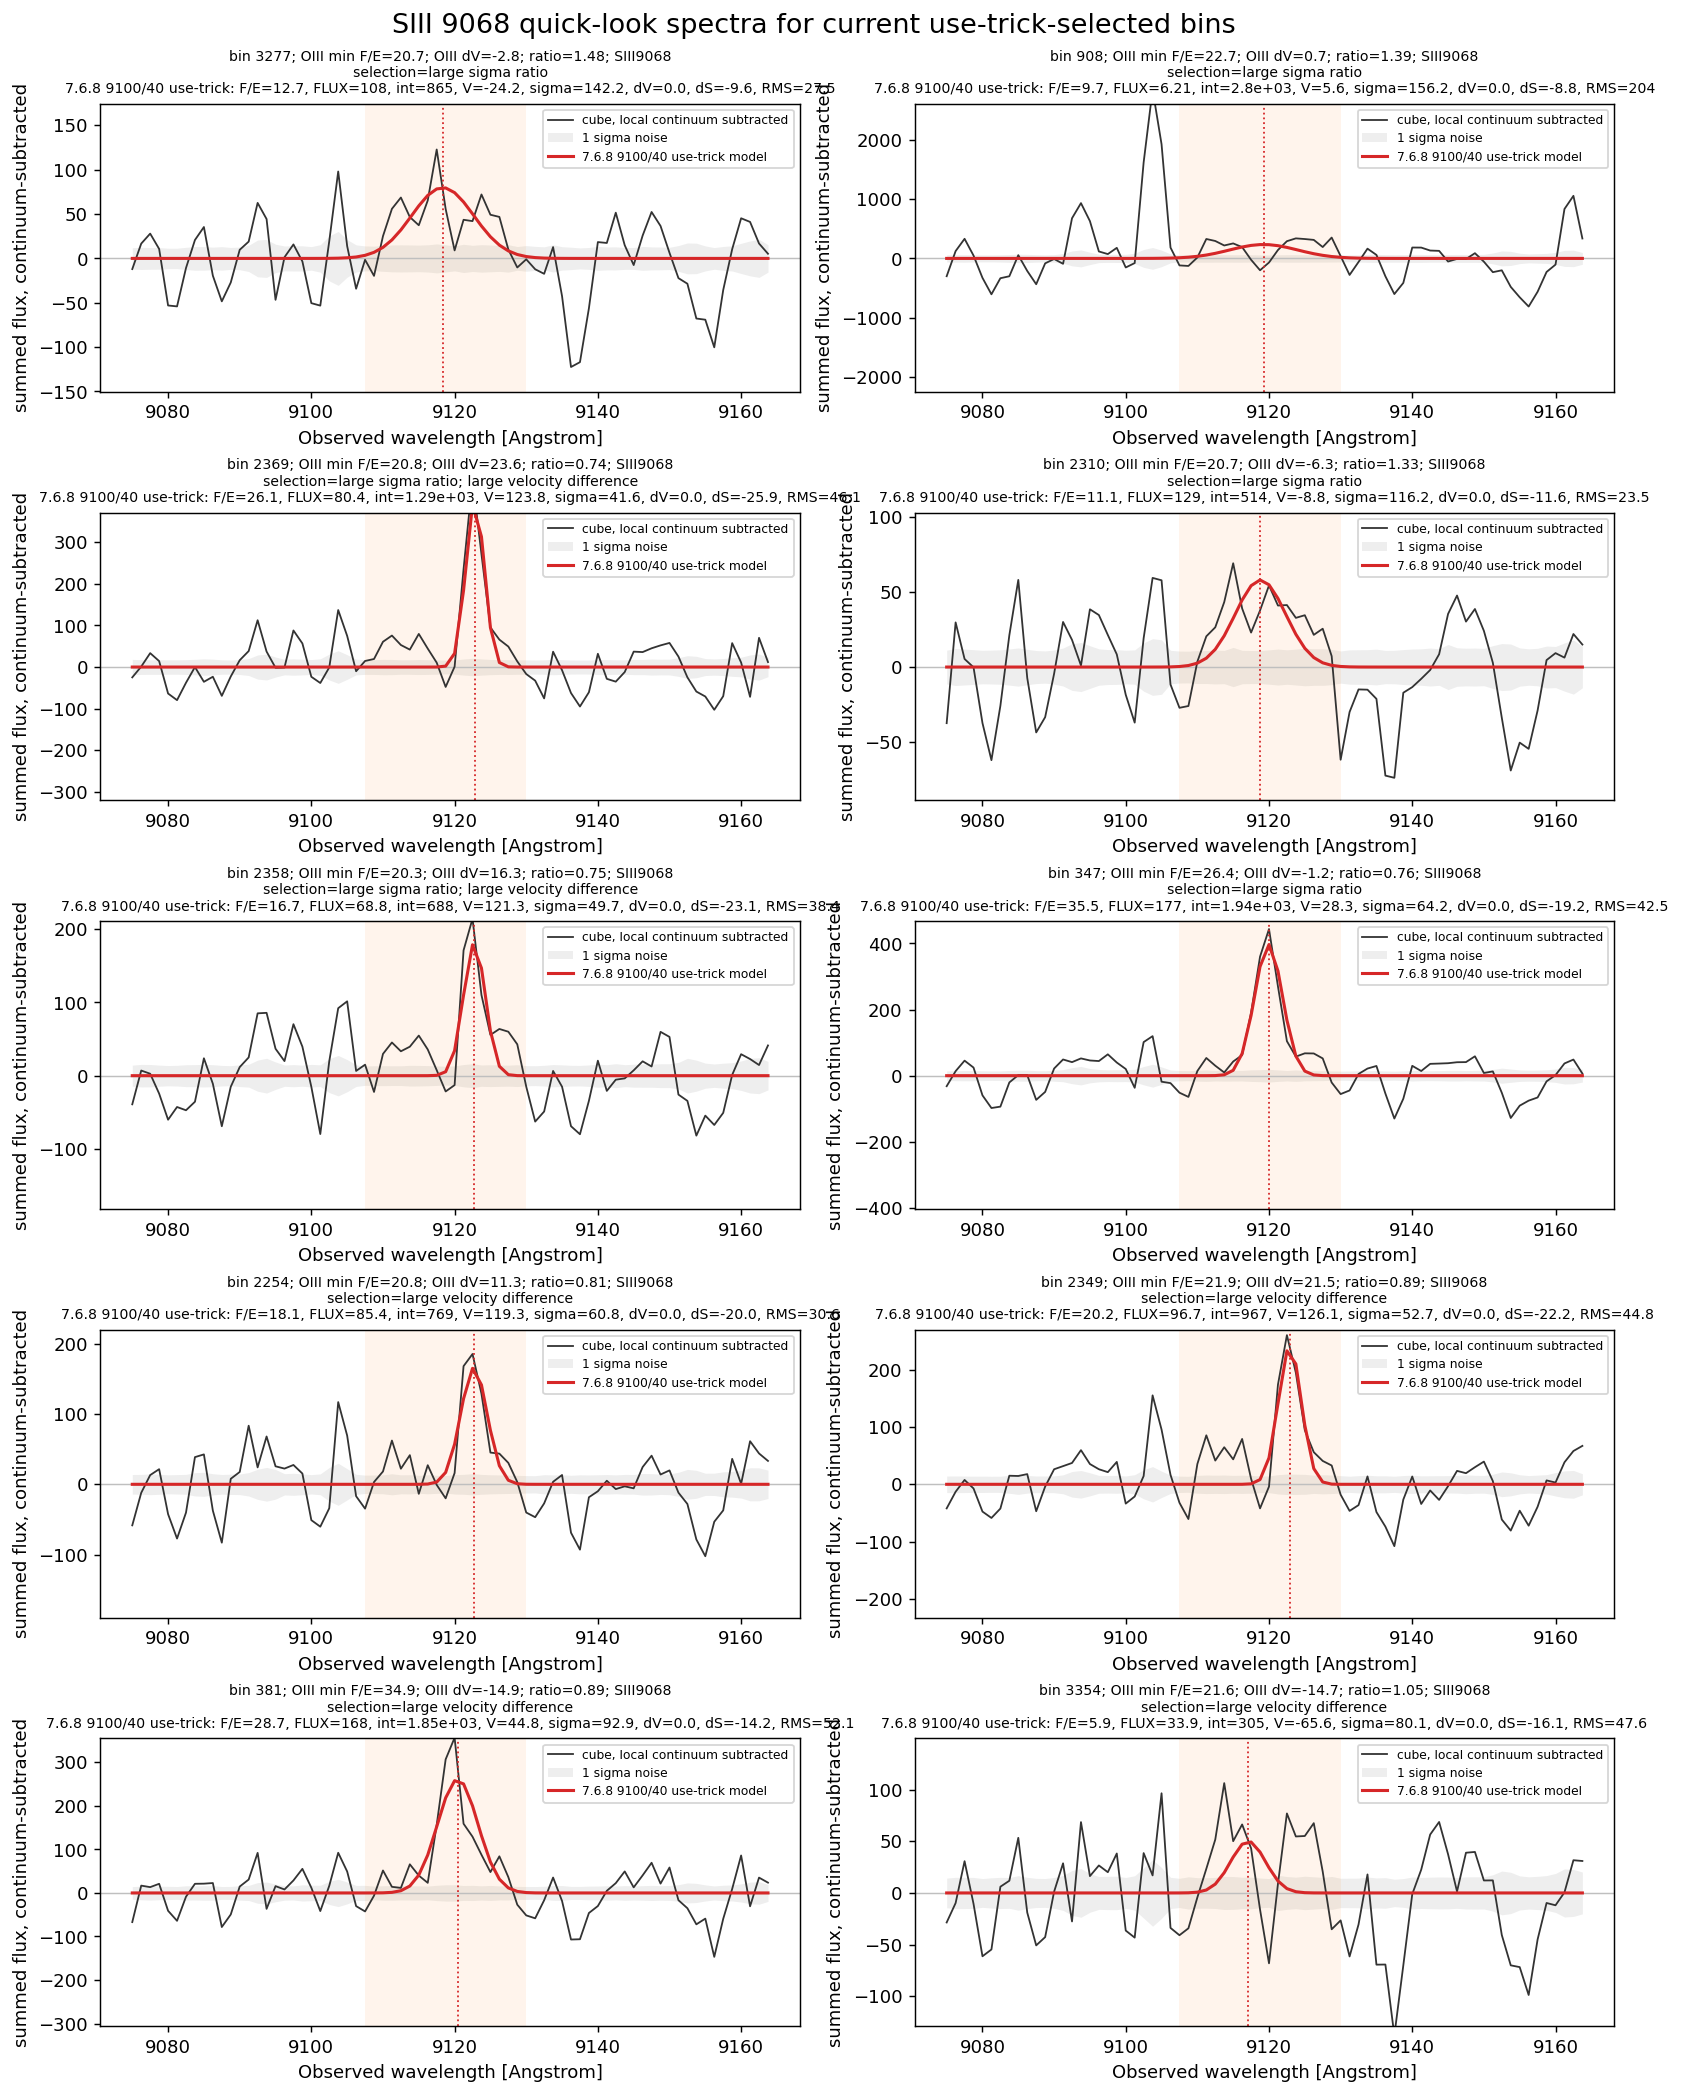

Extracted 10 spectra for SIII 6312 in previous full-line selected bins; model runs: 7.6.8 9100/40 use-trick.


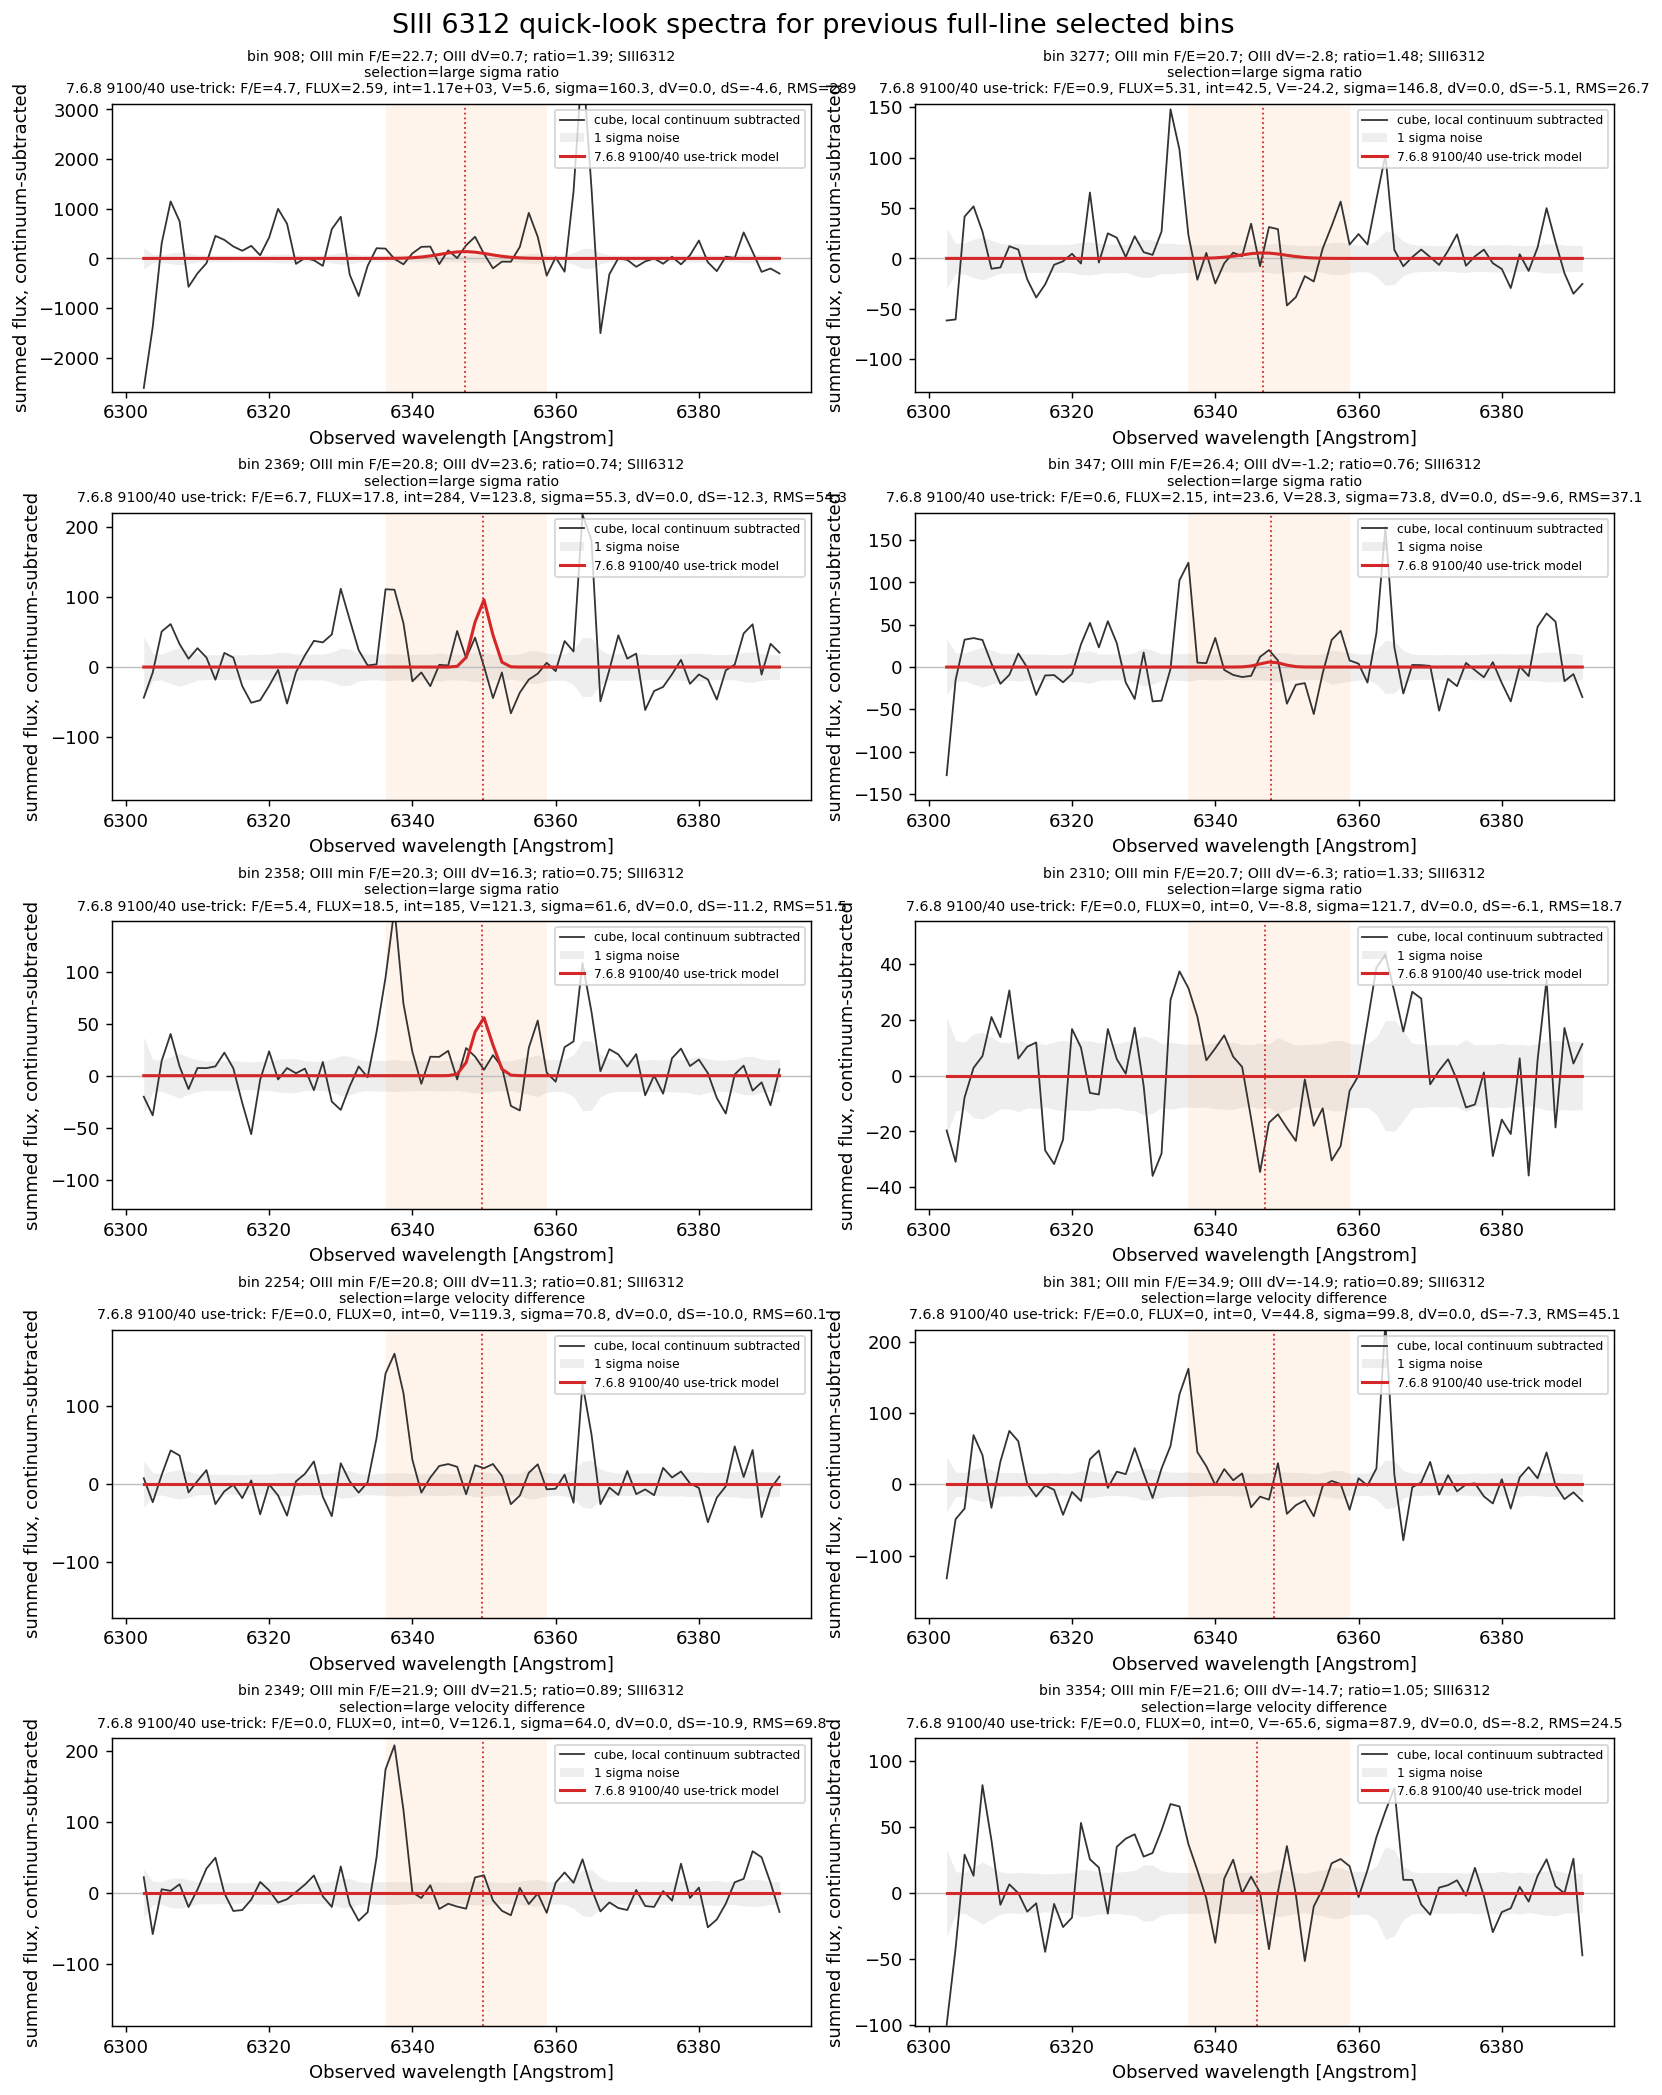

Extracted 10 spectra for SIII 9068 in previous full-line selected bins; model runs: 7.6.8 9100/40 use-trick.


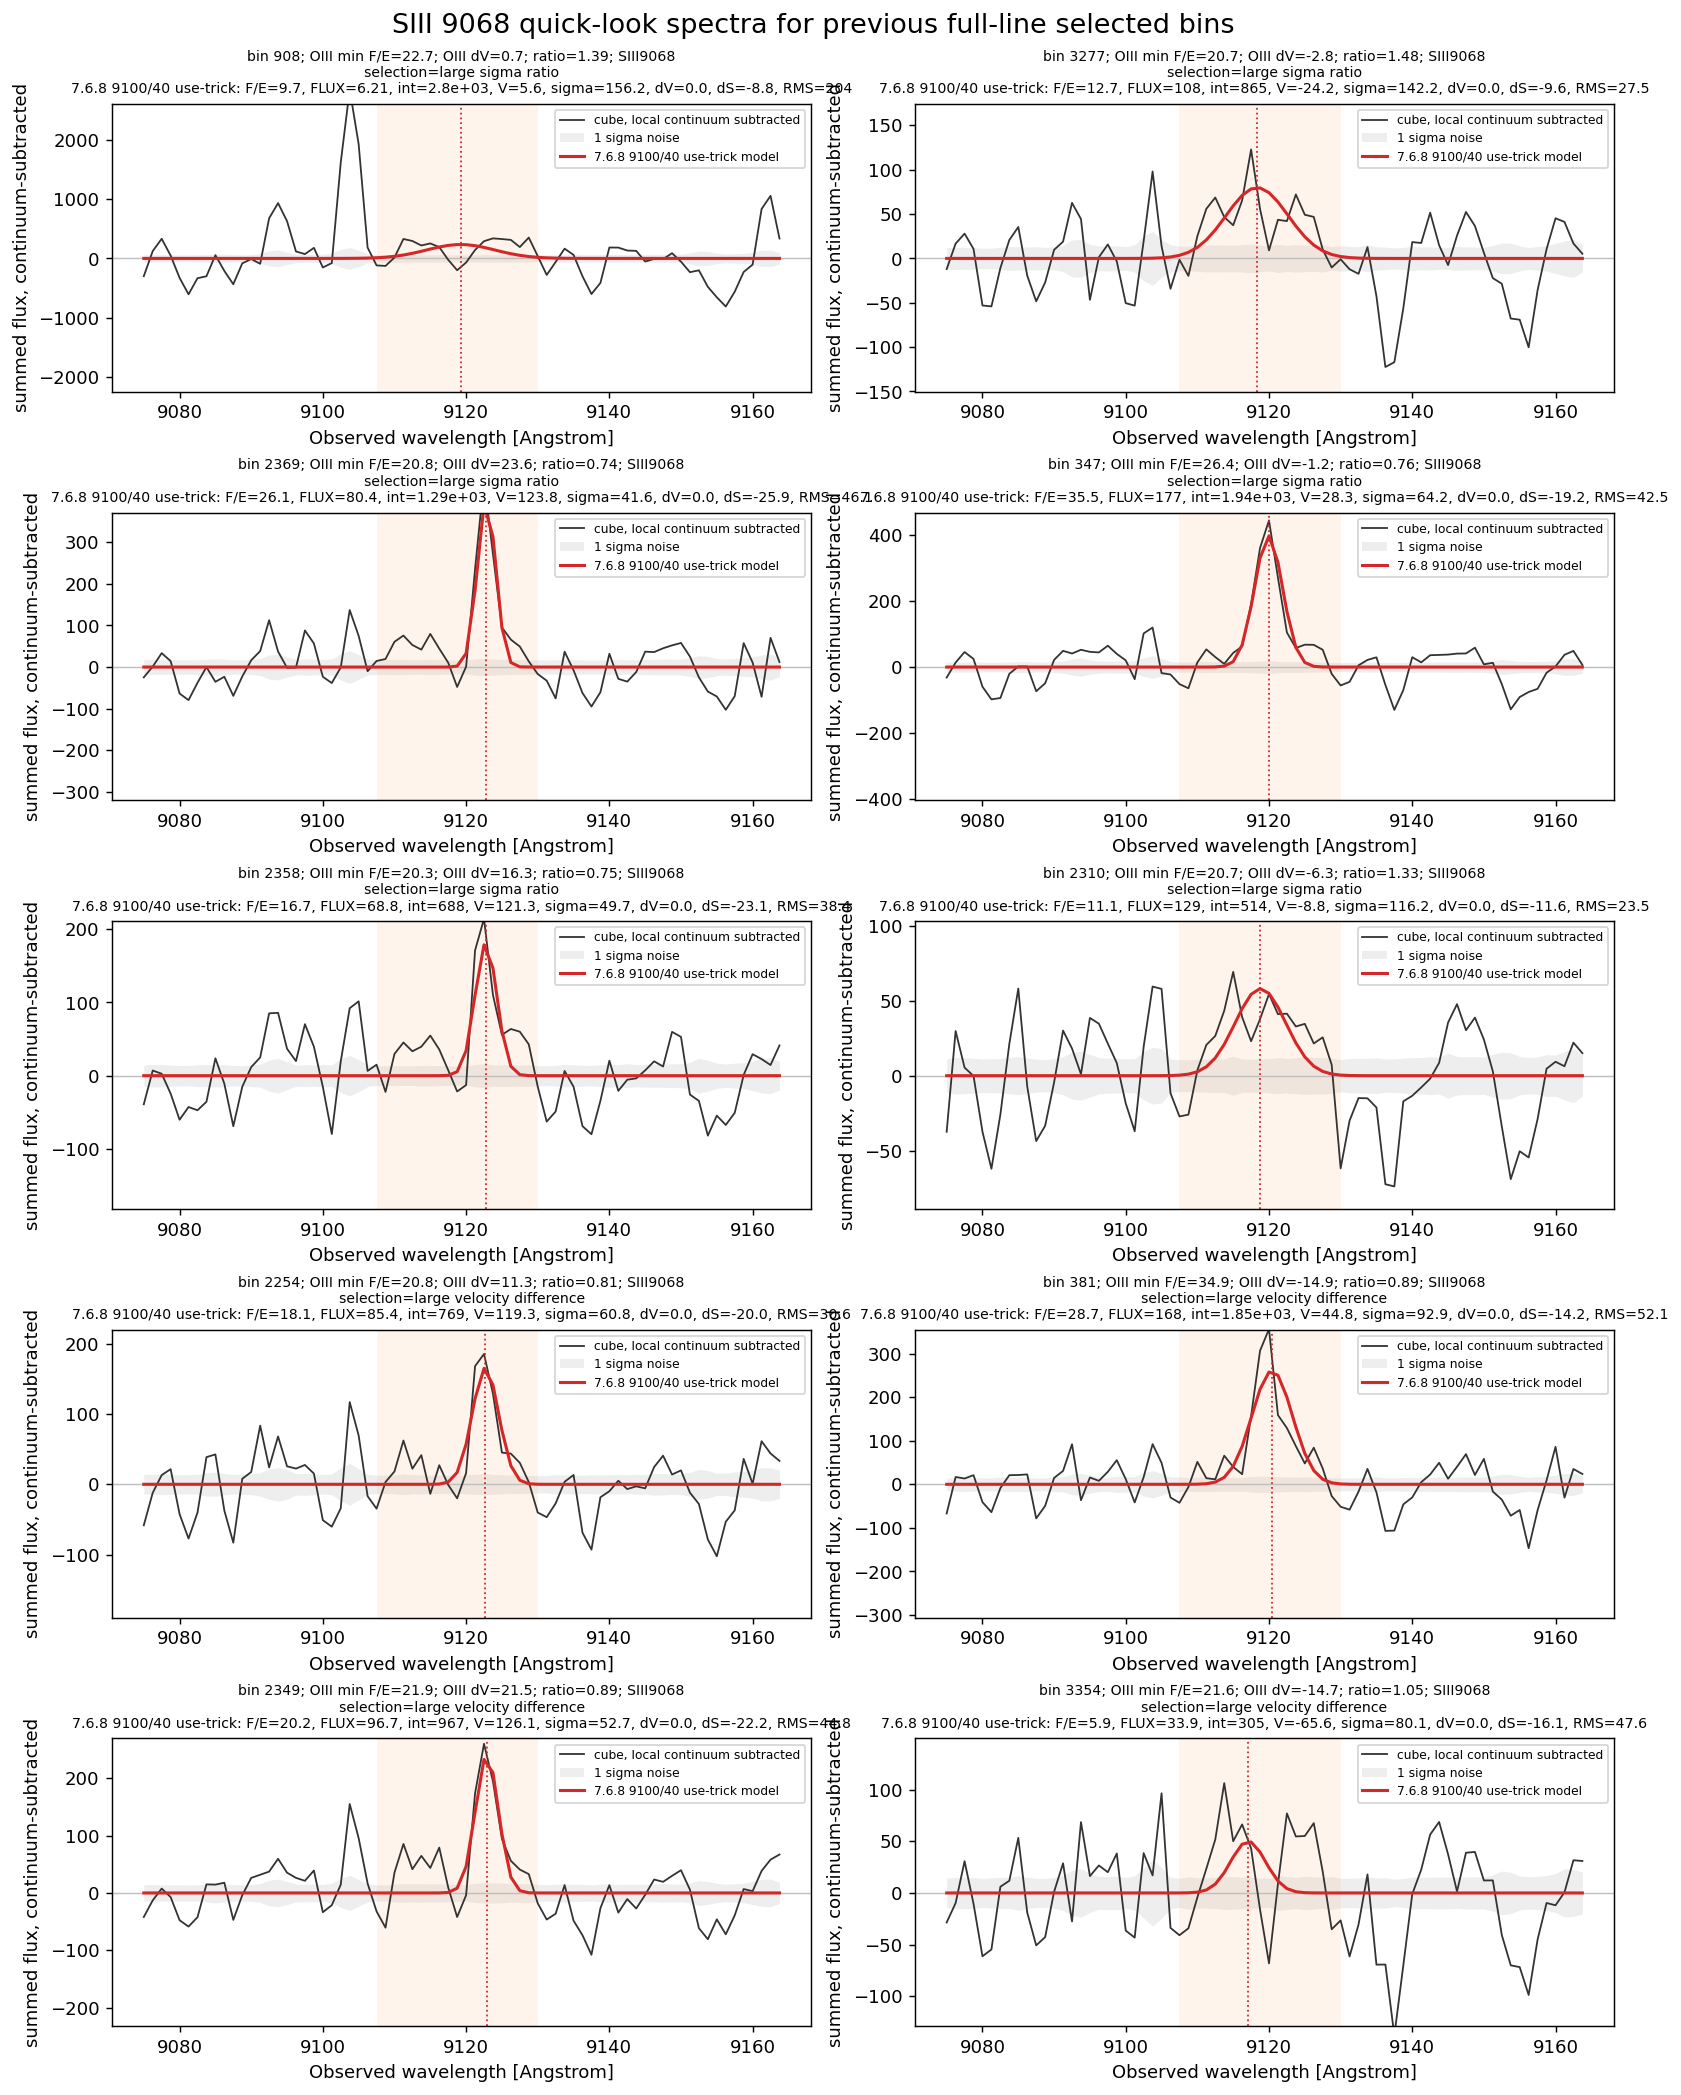

In [14]:
SIII_TARGET_LINE_IDS = ['SIII6312', 'SIII9068']
TIED_MODEL_RUNS = RUN_ORDER
RUN_PREFIX = {BASELINE_RUN: 'ref', COMPARE_RUN: 'cmp'}
TIED_REQUIRED_SUFFIXES = ['FLUX', 'FLUX_ERR', 'VEL', 'VEL_ERR', 'SIGMA', 'SIGMA_ERR', 'SIGMA_CORR']


def required_line_extensions(line_id):
    return [f'{line_id}_{suffix}' for suffix in TIED_REQUIRED_SUFFIXES]


comparison_config_lines = emission_tables[COMPARISON_EMISSION_CONFIG_KEY].copy()
siii_target_lines = (
    comparison_config_lines[comparison_config_lines['line_id'].isin(SIII_TARGET_LINE_IDS)]
    .copy()
    .assign(
        target_order=lambda df: df['line_id'].map({line_id: i for i, line_id in enumerate(SIII_TARGET_LINE_IDS)}),
        line_label=lambda df: df['name'] + ' ' + df['rest_air_a'].astype(int).astype(str),
    )
    .sort_values('target_order')
    .reset_index(drop=True)
)

missing_targets = [line_id for line_id in SIII_TARGET_LINE_IDS if line_id not in set(siii_target_lines['line_id'])]
if missing_targets:
    print('Warning: requested SIII target line(s) not found in use-trick emission config:', missing_targets)

run_extnames_by_run = {run_key: set(fits_extnames(RUNS[run_key]['gas_path'])) for run_key in TIED_MODEL_RUNS}


def finite_flux_pixel_count(run_key, line_id):
    extname = f'{line_id}_FLUX'
    if extname not in run_extnames_by_run[run_key]:
        return 0
    flux_map = read_map(RUNS[run_key]['gas_path'], extname)
    return int(np.count_nonzero(np.isfinite(flux_map)))


for run_key in TIED_MODEL_RUNS:
    prefix = RUN_PREFIX[run_key]
    extnames = run_extnames_by_run[run_key]
    siii_target_lines[f'missing_{prefix}'] = siii_target_lines['line_id'].map(
        lambda line_id: ', '.join([ext for ext in required_line_extensions(line_id) if ext not in extnames])
    )
    siii_target_lines[f'has_extensions_{prefix}'] = siii_target_lines[f'missing_{prefix}'].eq('')
    siii_target_lines[f'finite_flux_pixels_{prefix}'] = siii_target_lines.apply(
        lambda row: finite_flux_pixel_count(run_key, row['line_id']) if row[f'has_extensions_{prefix}'] else 0,
        axis=1,
    )
    siii_target_lines[f'available_{prefix}'] = (
        siii_target_lines[f'has_extensions_{prefix}']
        & (siii_target_lines[f'finite_flux_pixels_{prefix}'] > 0)
    )

siii_target_lines['available_runs'] = siii_target_lines.apply(
    lambda row: ', '.join([
        RUNS[run_key]['plot_label']
        for run_key in TIED_MODEL_RUNS
        if row[f'available_{RUN_PREFIX[run_key]}']
    ]),
    axis=1,
)
siii_target_lines['available_for_quicklook'] = siii_target_lines['available_runs'].ne('')

siii_availability_cols = [
    'line_id', 'line_label', 'rest_air_a', 'active_fit', 'mode',
    'has_extensions_ref', 'finite_flux_pixels_ref', 'available_ref',
    'has_extensions_cmp', 'finite_flux_pixels_cmp', 'available_cmp',
    'available_runs', 'missing_ref', 'missing_cmp',
]
display(siii_target_lines[siii_availability_cols])

available_siii_lines = siii_target_lines[siii_target_lines['available_for_quicklook']].copy().reset_index(drop=True)
print(f'Requested SIII lines found in use-trick config: {len(siii_target_lines)}')
print(f'Model-plottable in at least one GAS map: {len(available_siii_lines)}')


def median_map_value_for_bin(arr, bin_id):
    values = arr[baseline_bins == int(bin_id)]
    values = values[np.isfinite(values)]
    return float(np.nanmedian(values)) if values.size else np.nan


siii_line_maps = {}
for _, line in available_siii_lines.iterrows():
    line_id = line['line_id']
    siii_line_maps[line_id] = {}
    for run_key in TIED_MODEL_RUNS:
        prefix = RUN_PREFIX[run_key]
        if not bool(line[f'available_{prefix}']):
            continue
        siii_line_maps[line_id][run_key] = {
            suffix.lower(): read_map(RUNS[run_key]['gas_path'], f'{line_id}_{suffix}')
            for suffix in TIED_REQUIRED_SUFFIXES
        }


SIII_SELECTION_SETS = {
    'current_use_trick_selection': {
        'label': 'current use-trick-selected bins',
        'table': selected_bins.head(N_SPECTRA_TO_PLOT).copy(),
        'reason_col': 'selection_reason',
    },
    'previous_full_line_selection': {
        'label': 'previous full-line selected bins',
        'table': previous_full_line_selected_bins.head(N_SPECTRA_TO_PLOT).copy(),
        'reason_col': 'previous_full_line_selection_reason',
    },
}


def siii_selected_row(oiii_row, line, selection_key, selection_label, reason_col):
    line_id = line['line_id']
    bin_id = int(oiii_row['bin_id'])
    out = {
        'selection_key': selection_key,
        'selection_label': selection_label,
        'selection_reason': oiii_row.get(reason_col, ''),
        'line_id': line_id,
        'line_label': line['line_label'],
        'rest_air_a': line['rest_air_a'],
        'bin_id': bin_id,
        'row': oiii_row['row'],
        'col': oiii_row['col'],
        'n_spaxels': oiii_row['n_spaxels'],
        'oiii_min_fluxerr': oiii_row['both_fluxerr_min'],
        'oiii_delta_vel': oiii_row['delta_vel'],
        'oiii_sigma_ratio': oiii_row['sigma_ratio'],
    }

    for run_key in TIED_MODEL_RUNS:
        prefix = RUN_PREFIX[run_key]
        available = bool(line[f'available_{prefix}'])
        out[f'{prefix}_available'] = available
        if not available:
            for col in [
                'line_flux', 'line_flux_err', 'line_fluxerr', 'line_vel', 'line_sigma',
                'line_vel_err', 'line_sigma_err', 'line_sigma_corr',
                'line_minus_oiii_vel', 'line_minus_oiii_sigma',
            ]:
                out[f'{prefix}_{col}'] = np.nan
            continue

        line_maps = siii_line_maps[line_id][run_key]
        flux = median_map_value_for_bin(line_maps['flux'], bin_id)
        flux_err = median_map_value_for_bin(line_maps['flux_err'], bin_id)
        fluxerr = flux / flux_err if np.isfinite(flux) and np.isfinite(flux_err) and flux_err > 0 else np.nan
        vel = median_map_value_for_bin(line_maps['vel'], bin_id)
        sigma = median_map_value_for_bin(line_maps['sigma'], bin_id)
        vel_err = median_map_value_for_bin(line_maps['vel_err'], bin_id)
        sigma_err = median_map_value_for_bin(line_maps['sigma_err'], bin_id)
        sigma_corr = median_map_value_for_bin(line_maps['sigma_corr'], bin_id)
        oiii_vel = oiii_row[f'{prefix}_vel']
        oiii_sigma = oiii_row[f'{prefix}_sigma']
        out.update({
            f'{prefix}_line_flux': flux,
            f'{prefix}_line_flux_err': flux_err,
            f'{prefix}_line_fluxerr': fluxerr,
            f'{prefix}_line_vel': vel,
            f'{prefix}_line_sigma': sigma,
            f'{prefix}_line_vel_err': vel_err,
            f'{prefix}_line_sigma_err': sigma_err,
            f'{prefix}_line_sigma_corr': sigma_corr,
            f'{prefix}_line_minus_oiii_vel': vel - oiii_vel,
            f'{prefix}_line_minus_oiii_sigma': sigma - oiii_sigma,
        })
    return out


if available_siii_lines.empty:
    siii_selected_summary = pd.DataFrame()
else:
    siii_selected_summary = pd.DataFrame([
        siii_selected_row(oiii_row, line, selection_key, selection['label'], selection['reason_col'])
        for selection_key, selection in SIII_SELECTION_SETS.items()
        for _, line in available_siii_lines.iterrows()
        for _, oiii_row in selection['table'].iterrows()
    ])

siii_summary_cols = [
    'selection_label', 'line_id', 'bin_id', 'selection_reason', 'oiii_min_fluxerr',
    'oiii_delta_vel', 'oiii_sigma_ratio',
    'ref_available', 'ref_line_fluxerr', 'ref_line_minus_oiii_vel', 'ref_line_minus_oiii_sigma',
    'cmp_available', 'cmp_line_fluxerr', 'cmp_line_minus_oiii_vel', 'cmp_line_minus_oiii_sigma',
]
if siii_selected_summary.empty:
    print('No available SIII spectra to summarize or plot.')
else:
    display(siii_selected_summary[siii_summary_cols])


def fitted_siii_gaussian(wave, spectrum_contsub, row, run_key, line_window_mask):
    prefix = RUN_PREFIX[run_key]
    vel = row[f'{prefix}_line_vel']
    sigma_kms = row[f'{prefix}_line_sigma']
    rest_air_a = row['rest_air_a']
    map_flux = row[f'{prefix}_line_flux']
    n_spaxels = row['n_spaxels']
    center = rest_air_a * (1.0 + REDSHIFT) * (1.0 + vel / C_KMS)
    sigma_a = center * sigma_kms / C_KMS
    profile = gaussian_unit(wave, center, sigma_a)

    # The plotted cube spectrum is summed over all spaxels in this BIN_ID.
    # The GAS map repeats the per-bin FLUX value on each spaxel, so normalize
    # the visual model to FLUX * n_spaxels on the plotted wavelength grid.
    target_integrated_flux = map_flux * n_spaxels if np.isfinite(map_flux) and np.isfinite(n_spaxels) else np.nan
    profile_integral = np.trapezoid(profile, wave) if np.isfinite(profile).any() else np.nan
    if np.isfinite(target_integrated_flux) and np.isfinite(profile_integral) and profile_integral != 0:
        amp = target_integrated_flux / profile_integral
        model = amp * profile
        model_integral = np.trapezoid(model, wave)
    else:
        amp = np.nan
        model = np.full(wave.shape, np.nan)
        model_integral = np.nan

    fit_mask = line_window_mask & np.isfinite(model) & np.isfinite(spectrum_contsub)
    rms = np.sqrt(np.nanmean((spectrum_contsub[fit_mask] - model[fit_mask]) ** 2)) if fit_mask.sum() >= 3 else np.nan
    return {
        'center': center,
        'sigma_a': sigma_a,
        'amp': amp,
        'map_flux': map_flux,
        'target_integrated_flux': target_integrated_flux,
        'model_integral': model_integral,
        'model': model,
        'rms': rms,
        'vel': vel,
        'sigma_kms': sigma_kms,
    }


def extract_siii_line_spectra(line_summary, wave_half_width=45.0, line_half_width=12.0, continuum_inner=20.0):
    if CUBE_PATH is None:
        print('No local cube found; skipping SIII spectral extraction.')
        return []
    if line_summary.empty:
        return []

    rest_air_a = float(line_summary['rest_air_a'].iloc[0])
    line_label = line_summary['line_label'].iloc[0]
    systemic_center = rest_air_a * (1.0 + REDSHIFT)
    with fits.open(CUBE_PATH, memmap=True) as hdul:
        cube = hdul['DATA'].data
        var = hdul['STAT'].data if 'STAT' in hdul else None
        wave = wavelength_from_header(hdul['DATA'].header, cube.shape[0])
        wave_mask = (wave >= systemic_center - wave_half_width) & (wave <= systemic_center + wave_half_width)
        if not np.any(wave_mask):
            print(f'No cube wavelength coverage for {line_label} around {systemic_center:.1f} Angstrom.')
            return []
        wave_cut = wave[wave_mask]
        cube_cut = np.array(cube[wave_mask, :, :], dtype=float)
        var_cut = np.array(var[wave_mask, :, :], dtype=float) if var is not None else None

    line_window = np.abs(wave_cut - systemic_center) <= line_half_width
    continuum_window = (np.abs(wave_cut - systemic_center) >= continuum_inner) & np.isfinite(wave_cut)
    spectra = []

    for _, row in line_summary.iterrows():
        bin_id = int(row['bin_id'])
        bin_mask = baseline_bins == bin_id
        if not np.any(bin_mask):
            continue
        spectrum = np.nansum(cube_cut[:, bin_mask], axis=1)
        if var_cut is not None:
            variance = np.nansum(var_cut[:, bin_mask], axis=1)
            noise = np.sqrt(np.clip(variance, 0, np.inf))
        else:
            noise = np.full_like(spectrum, np.nan)

        continuum_fit_mask = continuum_window & np.isfinite(spectrum)
        if continuum_fit_mask.sum() >= 4:
            coeff = np.polyfit(wave_cut[continuum_fit_mask], spectrum[continuum_fit_mask], deg=1)
            continuum = np.polyval(coeff, wave_cut)
        else:
            continuum = np.full_like(spectrum, np.nanmedian(spectrum))
        contsub = spectrum - continuum
        fits_by_run = {
            run_key: fitted_siii_gaussian(wave_cut, contsub, row, run_key, line_window)
            for run_key in TIED_MODEL_RUNS
            if bool(row[f'{RUN_PREFIX[run_key]}_available'])
        }
        spectra.append({
            'bin_id': bin_id,
            'row': row,
            'wave': wave_cut,
            'spectrum': spectrum,
            'noise': noise,
            'continuum': continuum,
            'contsub': contsub,
            'line_window': line_window,
            'fits_by_run': fits_by_run,
        })
    return spectra


def format_siii_run_stat(row, run_key, fit):
    prefix = RUN_PREFIX[run_key]
    short_label = RUNS[run_key]['plot_label']
    return (
        f'{short_label}: F/E={row[f"{prefix}_line_fluxerr"]:.1f}, '
        f'FLUX={fit["map_flux"]:.3g}, int={fit["model_integral"]:.3g}, '
        f'V={row[f"{prefix}_line_vel"]:.1f}, sigma={row[f"{prefix}_line_sigma"]:.1f}, '
        f'dV={row[f"{prefix}_line_minus_oiii_vel"]:.1f}, dS={row[f"{prefix}_line_minus_oiii_sigma"]:.1f}, '
        f'RMS={fit["rms"]:.3g}'
    )


def plot_siii_line_spectra(selection_label, line_summary, spectra):
    if not spectra:
        line_label = line_summary['line_label'].iloc[0] if not line_summary.empty else 'SIII line'
        print(f'No spectra to plot for {line_label} in {selection_label}.')
        return
    n = len(spectra)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    line_label = spectra[0]['row']['line_label']
    fig, axes = plt.subplots(nrows, ncols, figsize=(12.4, 3.2 * nrows), squeeze=False, constrained_layout=True)
    fig.suptitle(f'{line_label} quick-look spectra for {selection_label}', fontsize=15)

    for ax, spec in zip(axes.ravel(), spectra):
        row = spec['row']
        wave = spec['wave']
        contsub = spec['contsub']
        line_window = spec['line_window']
        finite_contsub = contsub[np.isfinite(contsub)]
        y_scale = np.nanpercentile(np.abs(finite_contsub), 98) if finite_contsub.size else 1.0
        y_scale = y_scale if np.isfinite(y_scale) and y_scale > 0 else 1.0

        ax.axhline(0, color='0.75', linewidth=0.8)
        ax.plot(wave, contsub, color='0.2', linewidth=1.0, label='cube, local continuum subtracted')
        if np.isfinite(spec['noise']).any():
            ax.fill_between(wave, -spec['noise'], spec['noise'], color='0.7', alpha=0.22, linewidth=0, label='1 sigma noise')
        if np.any(line_window):
            ax.axvspan(wave[line_window].min(), wave[line_window].max(), color='tab:orange', alpha=0.08, linewidth=0)

        run_subtitles = []
        for run_key, fit in spec['fits_by_run'].items():
            ax.plot(wave, fit['model'], color=RUNS[run_key]['color'], linewidth=1.7, label=f'{RUNS[run_key]["plot_label"]} model')
            ax.axvline(fit['center'], color=RUNS[run_key]['color'], linestyle=':', linewidth=1)
            run_subtitles.append(format_siii_run_stat(row, run_key, fit))

        title = (
            f'bin {int(row["bin_id"])}; OIII min F/E={row["oiii_min_fluxerr"]:.1f}; '
            f'OIII dV={row["oiii_delta_vel"]:.1f}; ratio={row["oiii_sigma_ratio"]:.2f}; {row["line_id"]}'
        )
        subtitle = f'selection={row["selection_reason"]}\n' + '\n'.join(run_subtitles)
        ax.set_title(title + '\n' + subtitle, fontsize=7.8)
        ax.set_xlabel('Observed wavelength [Angstrom]')
        ax.set_ylabel('summed flux, continuum-subtracted')
        ax.set_ylim(-1.25 * y_scale, 1.45 * y_scale)
        ax.legend(loc='upper right', fontsize=6.8, frameon=True)

    for ax in axes.ravel()[len(spectra):]:
        ax.axis('off')
    plt.show()


siii_spectra_by_selection_and_line = {}
for selection_key, selection in SIII_SELECTION_SETS.items():
    selection_label = selection['label']
    siii_spectra_by_selection_and_line[selection_key] = {}
    for _, line in available_siii_lines.iterrows():
        line_id = line['line_id']
        line_summary = siii_selected_summary[
            (siii_selected_summary['selection_key'] == selection_key)
            & (siii_selected_summary['line_id'] == line_id)
        ].head(N_SPECTRA_TO_PLOT).copy()
        spectra = extract_siii_line_spectra(line_summary)
        siii_spectra_by_selection_and_line[selection_key][line_id] = spectra
        available_labels = [
            RUNS[run_key]['plot_label']
            for run_key in TIED_MODEL_RUNS
            if bool(line[f'available_{RUN_PREFIX[run_key]}'])
        ]
        print(
            f'Extracted {len(spectra)} spectra for {line["line_label"]} in {selection_label}; '
            f'model runs: {", ".join(available_labels)}.'
        )
        plot_siii_line_spectra(selection_label, line_summary, spectra)


## Optional Save

Uncomment these lines if you want CSV tables for follow-up notes or manual inspection.


In [15]:
# population_summary.to_csv('IC3392_OIII_fluxerr_population_20260514_use_trick.csv', index=False)
# selected_bins[selected_cols].to_csv('IC3392_OIII_highSN_selected_outlier_bins_20260514_use_trick.csv', index=False)
# bin_table.to_csv('IC3392_OIII_one_row_per_bin_20260514_use_trick.csv', index=False)
# siii_selected_summary.to_csv('IC3392_SIII_quicklook_selected_bins_20260514_use_trick.csv', index=False)
